# Prediksi Flare Matahari dari Magnetogram SDO/HMI

**Pertanyaan yang ingin dijawab:** dengan melihat kondisi medan magnet sebuah
wilayah aktif (AR) di Matahari **sekarang**, apakah wilayah itu akan melepaskan
flare kelas **M atau lebih** dalam **24 jam ke depan**?

Jadi ini soal klasifikasi biner. Satu baris data berarti satu wilayah aktif pada
satu jam tertentu, dan jawabannya cuma "ya, akan flare" atau "tidak".

Notebook ini hanya menjalankan dan menampilkan hasil. Kodenya sendiri ada di
paket [`flare_pipeline/`](flare_pipeline/), supaya bisa diuji terpisah dan
dipakai ulang di luar notebook.

Syarat sebelum menjalankan: email sudah terdaftar di JSOC. Caranya ada di
[DATA_GUIDE.md](DATA_GUIDE.md).

## Alur notebook secara keseluruhan

| Bagian | Yang dikerjakan | Keluarannya |
|---|---|---|
| 1-2 | Unduh data SHARP dan katalog flare, lalu saring barisnya | tabel baris yang layak dipakai |
| 3 | Tempelkan label "flare / tidak" pada tiap baris | kolom `y` |
| 4 | Pisah data menurut waktu | `train`, `val`, `test` |
| 5 | Latih semua model, kalibrasi, pilih ambang | laporan per model |
| 6-7 | Nilai dan bandingkan lewat tabel dan grafik | metrik dan 6 grafik diagnostik |
| 8 | Lihat fitur mana yang berpengaruh | grafik kepentingan fitur |
| 9 | Tingkat 4: CNN langsung di atas piksel | perbandingan akhir |
| 10 | Apa yang bisa dikerjakan setelah ini | daftar lanjutan |

## Urutan model yang dicoba, dan tujuan akhir masing-masing

Alih-alih langsung memakai model rumit, di sini dimulai dari tebakan paling
sederhana lalu naik pelan-pelan. Aturan mainnya: **tiap tingkat baru harus
mengalahkan tingkat sebelumnya pada data uji yang sama.** Kalau tidak,
kerumitan tambahannya tidak ada gunanya dan sebaiknya tidak dipakai.

| Tingkat | Model | Cara kerjanya | Tujuan akhir model ini |
|---|---|---|---|
| 0a | Climatology | Selalu menjawab angka yang sama, yaitu porsi flare di data latih | Menjadi **lantai paling dasar**. Model apa pun yang tidak bisa mengalahkannya berarti tidak belajar apa-apa. |
| 0b | Persistence | Aturan satu baris: "AR yang flare dalam 24 jam terakhir akan flare lagi" | Menjadi **pembanding yang jujur**. Ini aturan tanpa pelatihan yang dipakai di literatur, dan skornya sering mengejutkan. |
| 1 | Ambang satu fitur | Cari satu kolom SHARP dan satu angka potong yang memberi TSS terbaik | Menjawab: **apakah satu angka saja sudah cukup?** Kalau ya, seluruh mesin ML di bawahnya mubazir. |
| 2 | Regresi logistik | Gabungan linear dari 18 fitur | Model ML paling sederhana yang **koefisiennya masih bisa dibaca**, jadi kita tahu fitur mana yang dipakai. |
| 3 | Random Forest, Gradient Boosting | Kumpulan pohon keputusan | Menjawab: **apakah hubungan non-linear dan interaksi antar fitur menambah sesuatu** di atas model linear? |
| 4 | CNN pada citra magnetogram | Belajar langsung dari piksel Bz | Menjawab: **apakah masih ada informasi di dalam piksel** yang tidak tertangkap oleh 18 ringkasan SHARP buatan manusia? |

Yang paling penting dikalahkan adalah **tingkat 0b**. Climatology memang lantai
paling dasar, tapi Persistence adalah aturan yang benar-benar dipakai sebagai
pembanding di literatur, dan skornya sering lebih tinggi dari dugaan orang.

Tingkat 0 sampai 3 berjalan tanpa mengunduh satu pun berkas citra. Tingkat 4 di
bagian 9 butuh citra magnetogram dan PyTorch, dan keduanya opsional.

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from IPython.display import Image, display

from flare_pipeline.config import Config, quick_config
from flare_pipeline import evaluate as ev
from flare_pipeline.acquisition import fetch_sharp_metadata, fetch_goes_flare_catalog
from flare_pipeline.dataset import (quality_control, build_labeled_dataset,
                                    chronological_split, feature_columns,
                                    add_temporal_features)
from flare_pipeline.labeling import FlareIndex
from flare_pipeline.models import (ClimatologyBaseline, PersistenceBaseline,
                                   SingleFeatureThreshold, ProbabilityCalibrator,
                                   MODEL_FACTORY, extract_importance)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

# quick_config() = 2 tahun @ cadence 4 jam. Ganti ke Config() untuk 2010-2018.
cfg = quick_config()
cfg.jsoc_email = "erfan.ferdianto2003@gmail.com"   # <-- email JSOC Anda
cfg.ensure_dirs()
print(f"{cfg.start_time} .. {cfg.end_time} @ {cfg.sampling_cadence_hours}h")
print(f"target: flare >= {cfg.threshold_class}1.0 dalam {cfg.forecast_horizon_hours} jam")

2013-01-01 .. 2014-12-31 @ 4h
target: flare >= M1.0 dalam 24 jam


---
## 1. Mengambil data

**Tujuan bagian ini:** menyiapkan bahan mentahnya. Kita butuh dua sumber yang
nanti digabung, satu jadi masukan model (X) dan satu jadi jawaban yang ingin
ditebak (y).

**Sel di bawah akan:** mengunduh (atau membaca dari cache) metadata SHARP dan
katalog flare GOES, lalu menampilkan tiga baris pertama masing-masing.

### Fitur (X): metadata SHARP dari JSOC

Diambil dari seri `hmi.sharp_cea_720s` lewat pustaka `drms`. Isinya sekitar 20
angka per wilayah aktif per titik waktu: total fluks magnet, helisitas arus,
energi bebas medan, dan seterusnya.

Angka-angka ini dihitung JSOC langsung dari piksel magnetogram vektor di dalam
kotak wilayah aktif. Jadi walaupun kita tidak menyentuh satu pun file citra,
yang dipakai tetap data magnetogram, hanya sudah diringkas jadi beberapa angka.
File `.fits`-nya baru diperlukan di tingkat 4.

### Label (y): katalog flare GOES dari HEK

Diambil lewat `sunpy`. HEK dipilih karena tiap kejadiannya mencantumkan
`ar_noaanum`, yaitu nomor wilayah aktif tempat flare itu terjadi. Tanpa nomor
AR itu, sebuah flare tidak bisa dicocokkan ke HARP mana pun, sehingga tidak
bisa dipakai membuat label.

### Dua hal praktis

Hasil unduhan disimpan per bulan di `data/raw/`. Sel ini boleh dijalankan
berulang kali tanpa mengunduh ulang, dan boleh dihentikan di tengah jalan lalu
dilanjutkan nanti.

Soal format waktu: JSOC tidak menerima ISO-8601, tapi juga tidak memberi pesan
error kalau dikirimi format itu. Ia hanya mengembalikan tabel kosong, dan
akibatnya baru terasa jauh di belakang. Formatnya harus
`2014.01.01_00:00:00_TAI`. Konversinya sudah ditangani
`acquisition.to_jsoc_time()`.

In [2]:
df_sharp  = fetch_sharp_metadata(cfg)
df_flares = fetch_goes_flare_catalog(cfg)

display(df_sharp.head(3))
display(df_flares.head(3))

[SHARP] 2013-01 cache hit  (  2468 baris)
[SHARP] 2013-02 cache hit  (  2013 baris)
[SHARP] 2013-03 cache hit  (  2045 baris)
[SHARP] 2013-04 cache hit  (  2018 baris)
[SHARP] 2013-05 cache hit  (  2255 baris)
[SHARP] 2013-06 cache hit  (  2149 baris)
[SHARP] 2013-07 cache hit  (  2512 baris)
[SHARP] 2013-08 cache hit  (  2816 baris)
[SHARP] 2013-09 cache hit  (  2068 baris)
[SHARP] 2013-10 cache hit  (  2277 baris)
[SHARP] 2013-11 cache hit  (  2687 baris)
[SHARP] 2013-12 cache hit  (  2446 baris)
[SHARP] 2014-01 cache hit  (  2530 baris)
[SHARP] 2014-02 cache hit  (  2203 baris)
[SHARP] 2014-03 cache hit  (  2523 baris)
[SHARP] 2014-04 cache hit  (  3003 baris)
[SHARP] 2014-05 cache hit  (  2516 baris)


[SHARP] 2014-06 cache hit  (  2212 baris)
[SHARP] 2014-07 cache hit  (  2162 baris)
[SHARP] 2014-08 cache hit  (  2157 baris)
[SHARP] 2014-09 cache hit  (  2547 baris)
[SHARP] 2014-10 cache hit  (  2618 baris)
[SHARP] 2014-11 cache hit  (  2724 baris)
[SHARP] 2014-12 cache hit  (  2861 baris)
[SHARP] TOTAL 57486 baris, 1444 HARP unik.


[HEK] 2013 cache hit  ( 2062 flare)
[HEK] 2014 cache hit  ( 2252 flare)
[HEK] 4314 -> 4296 flare setelah deduplikasi; 521 tanpa asosiasi NOAA AR (dipakai hanya untuk klimatologi).


,T_REC,HARPNUM,NOAA_AR,NOAA_ARS,NOAA_NUM,LON_FWT,LAT_FWT,OBS_VR,QUALITY,CRLN_OBS,TOTUSJH,TOTBSQ,TOTPOT,TOTUSJZ,ABSNJZH,SAVNCPP,USFLUX,AREA_ACR,MEANPOT,R_VALUE,SHRGT45,MEANSHR,MEANGAM,MEANGBT,MEANGBZ,MEANGBH,MEANJZH,MEANJZD,MEANALP
0,2013-01-01 00:00:00,2322,11636,"11636,11637",2,15.194035,12.897586,1885.658159,0,327.052368,377.037,NaN,2.285518e+22,8.023545e+12,17.238,1.437391e+12,4.509503e+21,499.353577,2343.044,2.736,8.305,25.838,35.303,141.572,141.166,68.409,-0.002347,0.066735,-0.008345
1,2013-01-01 04:00:00,2322,11636,"11636,11637",2,17.351179,13.008873,1592.357941,0,324.862305,370.182,NaN,2.167782e+22,7.967899e+12,11.987,1.277934e+12,4.576674e+21,468.627289,2202.851,3.121,6.059,24.566,33.278,141.739,139.648,66.146,-0.001618,0.339018,-0.005919
2,2013-01-01 08:00:00,2322,11636,"11636,11637",2,19.500753,13.172722,-302.161158,0,322.683105,433.882,NaN,2.194442e+22,9.629252e+12,24.899,1.833843e+12,5.194983e+21,444.982880,1892.335,2.818,5.463,24.178,31.467,134.398,135.354,56.888,-0.002851,0.412782,-0.011263


,start_time,peak_time,end_time,goes_class,noaa_ar
0,2013-01-01 00:58:00,2013-01-01 01:03:00,2013-01-01 01:11:00,B7.8,0
1,2013-01-01 08:47:00,2013-01-01 09:06:00,2013-01-01 09:13:00,C1.2,11640
2,2013-01-01 14:26:00,2013-01-01 14:38:00,2013-01-01 14:56:00,B5.2,0


### Membaca keluaran sel di atas

**Baris `cache hit`** berarti bulan itu sudah pernah diunduh dan sekarang dibaca
dari `data/raw/`, tanpa menyentuh jaringan. Pada eksekusi pertama tulisannya
berbeda dan tiap bulan butuh waktu beberapa menit.

**Ukuran data SHARP.** Totalnya 57.486 baris dari 1.444 HARP. Satu baris artinya
satu wilayah aktif pada satu titik waktu, jadi AR yang bertahan seminggu
menyumbang puluhan baris sekaligus. Ini penting diingat: baris-baris itu tidak
saling bebas, dan akibatnya muncul lagi di bagian 4 dan bagian 6.

**Ukuran katalog flare.** Berisi 4.314 kejadian dan tinggal 4.296 setelah
duplikat dibuang. HEK memuat kejadian yang sama lebih dari sekali kalau
dilaporkan oleh lebih dari satu sumber. Ada 521 flare yang tidak mencantumkan
nomor NOAA AR; flare seperti itu tidak bisa dijodohkan ke HARP mana pun
sehingga tidak ikut membentuk label.

**Satu jebakan yang perlu dicatat.** Di tabel SHARP, kolom `TOTBSQ` isinya `NaN`
semua. Keyword itu memang ada di seri `hmi.sharp_720s`, tapi tidak ada di seri
CEA yang dipakai di sini, dan JSOC mengirimkan kolomnya begitu saja tanpa
keluhan. Kalau kolom itu sampai ikut dihitung sebagai fitur, satu panggilan
`dropna` akan menghapus **seluruh** dataset. Itu sebabnya `TOTBSQ` sengaja tidak
dimasukkan ke daftar `SHARP_FEATURES`.

---
## 2. Quality control

**Tujuan bagian ini:** membuang baris yang angkanya tidak bisa dipercaya,
sebelum angka itu sempat dipelajari model. Data yang cacat tidak menimbulkan
error, ia hanya membuat model belajar hal yang salah.

**Sel di bawah akan:** menjalankan empat filter berurutan, mencetak sisa baris
setelah tiap filter, lalu menampilkan lima baris pertama yang lolos.

| Filter | Kenapa perlu |
|---|---|
| `QUALITY == 0` | Membuang citra yang sebagian pikselnya hilang atau inversinya bermasalah. |
| `\|CMD\| <= 70°` | CMD adalah jarak sudut AR dari garis tengah cakram Matahari. Makin ke pinggir, makin miring sudut pandang kita terhadap permukaannya, dan parameter medan magnetnya makin tidak bisa dipercaya. |
| `\|OBS_VR\| <= 3500 m/s` | OBS_VR adalah kecepatan satelit mendekat atau menjauh dari Matahari. Kalau terlalu besar, efek Doppler menggeser garis serap yang dipakai mengukur medan magnet. |
| Fitur lengkap dan punya nomor NOAA AR | Baris tanpa nomor AR tidak bisa dijodohkan ke katalog flare, jadi labelnya tidak bisa dibuat. |

### Dua kesalahan yang sempat terjadi di sini

Keduanya layak dicatat karena **tidak menimbulkan pesan error sama sekali**.
Programnya jalan normal, hasilnya saja yang salah.

**Pertama, `LON_FWT` gampang disangka bujur Carrington.** Kalau memang
Carrington, CMD-nya harus dihitung dengan mengurangi `CRLN_OBS`. Ternyata tidak:
`drms.Client.info()` menyebut kolom itu bujur Stonyhurst, yang menurut
definisinya sudah diukur dari meridian tengah. Artinya `LON_FWT` itu sendiri
sudah merupakan CMD. Menguranginya lagi menghasilkan posisi di balik limb, dan
hampir semua baris terbuang.

**Kedua, cadence 6 jam dan 12 jam bermasalah.** SDO menjalankan manuver
kalibrasi tiap hari pada 06:00 dan 18:00 TAI, dan pada dua jam itu `QUALITY`
tidak pernah bernilai nol. Cadence kelipatan 6 jam akan selalu jatuh tepat di
sana dan kehilangan separuh data. Yang aman: 1, 2, atau 4 jam.

In [3]:
df_qc = quality_control(df_sharp, cfg)
df_qc[["T_REC", "HARPNUM", "NOAA_AR", "CMD_DEG", "USFLUX", "TOTUSJH", "R_VALUE"]].head()


[QC] Jejak penyaringan:
      awal                           57,486
      QUALITY == 0                   56,015   (-1,471)
      |CMD| <= 70.0deg               41,545   (-14,470)
      |OBS_VR| <= 3500 m/s           41,545
      fitur SHARP lengkap            41,502   (-43)
      punya NOAA AR                  21,239   (-20,263)



,T_REC,HARPNUM,NOAA_AR,CMD_DEG,USFLUX,TOTUSJH,R_VALUE
0,2013-01-01 00:00:00,2322,11636,15.194035,4.509503e+21,377.037,2.736
1,2013-01-01 04:00:00,2322,11636,17.351179,4.576674e+21,370.182,3.121
2,2013-01-01 08:00:00,2322,11636,19.500753,5.194983e+21,433.882,2.818
3,2013-01-01 12:00:00,2322,11636,21.757809,4.506961e+21,349.448,2.995
4,2013-01-01 16:00:00,2322,11636,23.985380,4.689083e+21,349.694,2.741


### Membaca jejak penyaringan

Angka di sebelah kanan tiap baris adalah **sisa baris setelah filter itu
dijalankan**, jadi selisihnya menunjukkan berapa yang dibuang tiap langkah.

**Pemotongan terbesar justru bukan soal kualitas citra,** melainkan syarat
terakhir: punya nomor NOAA AR. Sekitar 20 ribu baris hilang di situ, hampir
separuh dari yang masih tersisa waktu filter itu dijalankan.

Penyebabnya, HARP dibuat otomatis untuk tiap gumpalan medan magnet yang cukup
kuat, termasuk gumpalan kecil yang tidak pernah didaftarkan NOAA sebagai
wilayah aktif bernomor. Gumpalan sekecil itu praktis tidak pernah menghasilkan
flare kelas M, jadi membuangnya **tidak ikut membuang kejadian positif**. Yang
hilang hampir semuanya baris negatif.

**Pemotongan kedua, sekitar 14 ribu baris, datang dari batas CMD 70 derajat.**
Ini soal geometri. Makin dekat ke tepi cakram, makin miring sudut pandang kita
terhadap permukaan, dan komponen medan yang terukur makin tidak bisa dipercaya.

**Filter `OBS_VR` tidak membuang satu baris pun.** Nilai tertinggi yang muncul
pada rentang ini 3.490 m/s, tepat di bawah ambang 3.500. Filternya tetap
dipasang karena rentang data yang lebih panjang bisa saja melewatinya.

**Tabel di bawahnya** adalah lima baris pertama yang lolos. Perhatikan kolom
`CMD_DEG`: nilainya naik dari 15 ke 24 derajat dalam 16 jam. Itu rotasi Matahari
yang menggeser AR yang sama menjauhi meridian tengah.

---
## 3. Menentukan jendela waktu dan label

**Tujuan bagian ini:** memberi jawaban (`y`) pada tiap baris. Inilah yang
mengubah tabel pengamatan menjadi dataset yang bisa dilatih.

**Sel di bawah akan:** mencocokkan tiap baris SHARP dengan katalog flare,
membuat kolom `y` (0 atau 1) dan kolom `class_true` (kelas flare terkuat), lalu
mencetak sebarannya.

### Dua jendela waktu di sekitar tiap baris

Untuk tiap baris SHARP pada waktu `t`:

```
    [ t - 24 jam , t )              [ t , t + 24 jam ]
    jendela pengamatan              jendela prakiraan
    dipakai baseline Persistence    isinya menjadi label y
```

**Jendela pengamatan** berisi apa yang **sudah** terjadi, dan ini yang boleh
dilihat model. **Jendela prakiraan** berisi apa yang ingin **ditebak**, dan ini
yang jadi jawaban.

Keduanya tidak boleh bertumpang tindih. Kalau bertumpang tindih, model
"memprediksi" flare yang sebenarnya sudah lewat, dan skornya tidak berarti
apa-apa. Ini bentuk kebocoran data yang paling halus dan paling sering terjadi
pada masalah deret waktu.

Sebuah baris diberi **label 1** kalau flare terkuat di jendela prakiraan
mencapai kelas **M1.0 atau lebih**, dan **label 0** kalau tidak.

### Satu detail yang gampang salah

Perbandingan kekuatan flare dilakukan pada **nilai fluksnya dalam W/m²**, bukan
pada teks kelasnya. Membandingkan teks gagal pada magnitudo dua digit. Menurut
urutan teks `'X10.0' < 'X9.3'`, karena karakter `'1'` datang sebelum `'9'`.
Padahal X10.0 lebih dari sepuluh kali lebih kuat dari X9.3, dan flare sebesar
itu benar-benar ada. X17 dan X28 pada 2003 termasuk yang terkuat yang pernah
tercatat.

In [4]:
flares = FlareIndex(df_flares)
df = build_labeled_dataset(df_qc, flares, cfg)

print("\nSebaran kelas flare dalam window prakiraan:")
print(df["class_true"].value_counts().to_string())

[Label] 21,239 sampel | positif (>= M1.0 dalam 24h): 845 (3.98%)

Sebaran kelas flare dalam window prakiraan:
class_true
Q    15315
C     4073
B     1006
M      751
X       94


### Membaca sebaran kelas

Kolom `class_true` menghitung **flare terkuat yang muncul di jendela prakiraan**
tiap baris.

| Kelas | Jumlah baris | Artinya |
|---|---|---|
| Q | 15.315 | tidak ada flare sama sekali dalam 24 jam ke depan |
| C | 4.073 | flare terkuatnya kelas C |
| B | 1.006 | flare terkuatnya kelas B |
| M | 751 | **positif** |
| X | 94 | **positif** |

Polanya jelas: makin kuat kelasnya, makin jarang muncul.

**Label positif di notebook ini adalah M dan X digabung**, jadi 845 baris dari
21.239, atau **3,98%**. Angka kecil inilah yang membuat akurasi tidak berguna di
sini, dan alasan lengkapnya dibahas di bagian 6.

**Kalau ambangnya diturunkan** lewat `cfg.threshold_class = "C"`, jumlah positif
melonjak ke 4.918 baris atau 23,2%, dan seluruh angka di notebook ini ikut
berubah. Perlu diingat, prediksi flare kelas C **jauh lebih mudah** karena
kejadiannya jauh lebih sering, jadi hasilnya tidak bisa dibandingkan dengan
angka kelas M di literatur.

---
## 4. Membagi data menurut waktu, bukan acak

**Tujuan bagian ini:** memastikan skor yang keluar nanti benar-benar mengukur
kemampuan model, bukan kemampuannya menghafal. Ini bagian yang paling gampang
membuat seluruh hasil jadi bohong.

**Sel di bawah akan:** memotong data jadi `train` / `val` / `test` berdasarkan
urutan waktu, lalu mencetak daftar fitur yang dipakai.

### Kenapa pembagian acak berbahaya di sini

Baris SHARP dari AR yang sama pada jam berdekatan nilainya **nyaris identik**,
karena sebuah wilayah aktif tidak berubah banyak dalam 4 jam.

Kalau pembagian train/test dilakukan secara acak, tetangga langsung dari tiap
baris uji kemungkinan besar ikut masuk ke data latih. Model jadi seperti sudah
pernah melihat jawabannya. Skornya melonjak, padahal kemampuan aslinya tidak
berubah sedikit pun.

Karena itu pembagiannya **murni menurut waktu**: latih pada periode awal, uji
pada periode sesudahnya. Cara ini juga yang sesuai dengan pemakaian sebenarnya,
karena prakiraan selalu berarti menebak masa depan dari masa lalu.

**Patokan kasar:** TSS di atas 0,9 pada tugas ini hampir selalu tanda ada
kebocoran semacam ini. Kalau hasil Anda setinggi itu, curigai pembagian datanya
lebih dulu sebelum merayakan.

In [5]:
splits = chronological_split(df, cfg)
train, val, test = splits["train"], splits["val"], splits["test"]

feats = feature_columns(df)
print(f"{len(feats)} fitur: {feats}")


[Split] Pembagian kronologis:
      train    11,125 sampel | 2013-01-01 .. 2013-12-31 | positif 2.87% | 244 HARP
      val       5,604 sampel | 2013-12-31 .. 2014-06-30 | positif 5.64% | 114 HARP
      test      4,510 sampel | 2014-06-30 .. 2015-01-01 | positif 4.66% | 90 HARP

18 fitur: ['TOTUSJH', 'TOTPOT', 'TOTUSJZ', 'ABSNJZH', 'SAVNCPP', 'USFLUX', 'AREA_ACR', 'MEANPOT', 'R_VALUE', 'SHRGT45', 'MEANSHR', 'MEANGAM', 'MEANGBT', 'MEANGBZ', 'MEANGBH', 'MEANJZH', 'MEANJZD', 'MEANALP']


### Membaca hasil pembagian

**Perhatikan porsi positif di tiap potongan:** 2,87% di data latih, 5,64% di
validasi, dan 4,66% di data uji. Angkanya berbeda-beda padahal datanya sama.

Penyebabnya siklus Matahari. Data latih hampir seluruhnya 2013, sedangkan
validasi dan uji jatuh di 2014, dan siklus 24 memuncak sekitar April 2014.
Wilayah aktif pada periode yang lebih ramai lebih sering menghasilkan flare.

**Perbedaan ini punya akibat langsung waktu membaca hasil:**

- **TSS tidak terpengaruh** seberapa sering flare terjadi, jadi aman dipakai
  membandingkan model antar periode.
- **HSS terpengaruh**, jadi HSS dari dataset ini tidak bisa disandingkan begitu
  saja dengan HSS dari makalah yang memakai rentang tahun berbeda.

**Fitur yang terpakai ada 18, bukan 19.** `TOTBSQ` gugur otomatis karena seluruh
isinya `NaN`, sesuai yang sudah terlihat di bagian 1.

---
## 5. Melatih dan menilai model

**Tujuan bagian ini:** menjalankan seluruh tangga model dengan perlakuan yang
persis sama, supaya perbandingannya adil.

**Sel di bawah akan:** menyiapkan potongan data dan mendefinisikan fungsi
`assess()`, yang dipakai ulang oleh semua model sesudahnya.

### Empat langkah yang dilalui tiap model

| # | Langkah | Data yang dipakai |
|---|---|---|
| 1 | Dilatih | data latih |
| 2 | Probabilitas keluarannya dikalibrasi | paruh **pertama** validasi (`val_cal`) |
| 3 | Ambang keputusan dipilih, dicari yang memberi TSS tertinggi | paruh **kedua** validasi (`val_thr`) |
| 4 | Baru dinilai, memakai ambang yang sudah dikunci | data uji |

Data uji **tidak pernah disentuh** sampai langkah 4. Itulah yang membuat
angkanya bisa dipercaya.

### Kenapa perlu langkah 2 (kalibrasi)

`class_weight="balanced"` sengaja menggeser probabilitas keluaran supaya kelas
minoritas tidak tenggelam. Efek sampingnya, angka probabilitas itu tidak lagi
berarti "peluang sebenarnya". Model bisa bilang 0,8 untuk kejadian yang
sebenarnya cuma berpeluang 0,2.

Kalibrasi isotonik mengembalikan artinya **tanpa mengubah urutan skor**. Karena
urutannya tetap, TSS dan AUC juga tetap sama persis seperti sebelum
dikalibrasi. Yang berubah hanya angka probabilitasnya, dan itu baru terasa di
grafik reliabilitas nanti.

### Kenapa langkah 2 dan 3 memakai potongan yang berbeda

Kalau potongannya sama, ambang yang terpilih akan tampak lebih bagus daripada
kemampuan sebenarnya, karena dipilih pada data yang sudah dipakai menyesuaikan
probabilitasnya. Memisahkannya adalah versi kecil dari prinsip yang sama dengan
memisahkan data uji.

In [6]:
val_sorted = val.sort_values("T_REC")
cut = len(val_sorted) // 2
val_cal, val_thr = val_sorted.iloc[:cut], val_sorted.iloc[cut:]

Xtr, ytr = train[feats], train["y"].values
Xte, yte = test[feats],  test["y"].values
groups_te = test["HARPNUM"].values
clim = float(ytr.mean())

reports, probs, fitted = [], {}, {}

def assess(model, name, calibrate=True):
    if calibrate:
        model = ProbabilityCalibrator(model).fit(val_cal[feats], val_cal["y"].values)
    thr, tss_va = ev.best_threshold(val_thr["y"].values,
                                    model.predict_proba(val_thr[feats])[:, 1], "TSS")
    p_te = model.predict_proba(Xte)[:, 1]
    rep = ev.evaluate(yte, p_te, thr, groups_te, name, clim)
    reports.append(rep); probs[name] = p_te; fitted[name] = model
    ev.print_report(rep)
    return rep

### Tingkat 0 — dua lantai pembanding

**Tujuan dua model ini bukan untuk dipakai,** melainkan untuk jadi garis batas.
Model apa pun di tingkat atas yang tidak bisa mengalahkan keduanya berarti tidak
memberi nilai tambah apa pun, seberapa canggih pun isinya.

**0a. Climatology** selalu menjawab angka yang sama untuk semua baris, yaitu
porsi flare di data latih. Ia tidak melihat fitur sama sekali. Perannya adalah
lantai absolut: TSS-nya nol menurut definisi, dan itu titik nol yang dipakai
menilai semua model lain.

**0b. Persistence** memakai satu aturan tanpa pelatihan: kalau AR ini flare
dalam 24 jam terakhir, tebak ia akan flare lagi. Informasinya diambil dari
jendela pengamatan yang dibahas di bagian 3, jadi tidak ada kebocoran ke masa
depan.

Ini pembanding yang sebenarnya. Aturan sesederhana itu sudah cukup kuat karena
wilayah aktif yang produktif memang cenderung terus produktif selama beberapa
hari. Di literatur, model baru yang tidak bisa mengalahkan Persistence dianggap
belum membuktikan apa-apa.

Keduanya tidak dikalibrasi. Climatology keluarannya konstan dan Persistence
keluarannya sudah biner, jadi tidak ada yang bisa dikalibrasi.

In [7]:
# --- Tingkat 0a: Climatology (tanpa kalibrasi -- probabilitasnya konstan) ---
p = ClimatologyBaseline().fit(Xtr, ytr).predict_proba(Xte)[:, 1]
rep = ev.evaluate(yte, p, 0.5, groups_te, "0a. Climatology", clim)
reports.append(rep); probs["0a. Climatology"] = p
ev.print_report(rep)

# --- Tingkat 0b: Persistence (tanpa kalibrasi -- keluarannya sudah biner) ---
p = PersistenceBaseline().predict_proba(test["y_persistence"].values)[:, 1]
rep = ev.evaluate(yte, p, 0.5, groups_te, "0b. Persistence", clim)
reports.append(rep); probs["0b. Persistence"] = p
ev.print_report(rep)


  0a. Climatology   (ambang = 0.500, N = 4,510)
  Tabel kontingensi   hit=0      miss=210    false alarm=0       correct neg=4,300
  ----------------------------------------------------------------
  TSS (utama)      +0.0000  [+0.000, +0.000]
  HSS              +0.0000  [+0.000, +0.000]
  GSS / ETS        +0.0000
  MCC              +0.0000
  ----------------------------------------------------------------
  POD (recall)     0.0000      POFD  0.0000
  Precision        0.0000      FAR   0.0000
  F1               0.0000      CSI   0.0000
  Frequency bias   0.0000  (1.0 = jumlah peringatan pas)
  ----------------------------------------------------------------
  ROC-AUC          0.5000      PR-AUC  0.0466
  Brier            0.04472     BSS     +0.0000
  Accuracy         0.9534  (menyesatkan -- basis rate 4.66%)

  0b. Persistence   (ambang = 0.500, N = 4,510)
  Tabel kontingensi   hit=120    miss=90     false alarm=94      correct neg=4,206
  ----------------------------------------------

### Tingkat 1 — satu fitur, satu ambang

**Tujuan model ini:** menjawab apakah semua kerumitan ML di bawahnya memang
perlu. Kalau satu angka SHARP dengan satu garis potong sudah mendekati skor
Random Forest, maka pilihan yang masuk akal adalah memakai aturan satu baris
itu, karena jauh lebih mudah dijelaskan dan diaudit.

**Cara kerjanya:** coba semua kombinasi (kolom, ambang, arah perbandingan) pada
data latih, lalu ambil yang memberi TSS tertinggi. Hasilnya berupa aturan yang
bisa ditulis dalam satu kalimat, dan itu yang dicetak `sft.describe()`.

Pendekatan ini mengikuti Bloomfield et al. (2012) dan Barnes & Leka, dan masih
dipakai sebagai tolok ukur di banyak makalah prakiraan flare.

Perhatikan mana fitur yang terpilih waktu sel ini dijalankan — fitur itu akan
muncul lagi di bagian 8 sebagai fitur terpenting menurut Random Forest.

In [8]:
# --- Tingkat 1: ambang satu fitur ---
sft = SingleFeatureThreshold().fit(Xtr, ytr)
print("Aturan terpilih:", sft.describe())
assess(sft, "1. Ambang satu fitur")

Aturan terpilih: prakiraan positif bila R_VALUE >= 4.144 (TSS latih 0.722)

  1. Ambang satu fitur   (ambang = 0.046, N = 4,510)
  Tabel kontingensi   hit=193    miss=17     false alarm=1100    correct neg=3,200
  ----------------------------------------------------------------
  TSS (utama)      +0.6632  [+0.489, +0.768]
  HSS              +0.1921  [+0.084, +0.328]
  GSS / ETS        +0.1063
  MCC              +0.3090
  ----------------------------------------------------------------
  POD (recall)     0.9190      POFD  0.2558
  Precision        0.1493      FAR   0.8507
  F1               0.2568      CSI   0.1473
  Frequency bias   6.1571  (1.0 = jumlah peringatan pas)
  ----------------------------------------------------------------
  ROC-AUC          0.9239      PR-AUC  0.5297
  Brier            0.02933     BSS     +0.3440
  Accuracy         0.7523  (menyesatkan -- basis rate 4.66%)


{'model': '1. Ambang satu fitur',
 'threshold': 0.0461,
 'TP': 193,
 'FP': 1100,
 'FN': 17,
 'TN': 3200,
 'N': 4510,
 'base_rate': 0.04656319290465632,
 'POD': 0.919047619047619,
 'POFD': 0.2558139534883721,
 'FAR': 0.8507347254447022,
 'Precision': 0.1492652745552978,
 'Recall': 0.919047619047619,
 'Specificity': 0.7441860465116279,
 'F1': 0.25681969394544246,
 'CSI': 0.14732824427480917,
 'FrequencyBias': 6.1571428571428575,
 'TSS': 0.6632336655592469,
 'HSS': 0.19209458148303174,
 'GSS': 0.10625256139815528,
 'MCC': 0.3090193289042863,
 'Accuracy': 0.7523281596452328,
 'ROC_AUC': 0.9239418604651164,
 'PR_AUC': 0.529655101852968,
 'Brier': 0.02933208393695116,
 'BSS': 0.3440225485072344,
 'Climatology': 0.028674157303370786,
 'TSS_lo': 0.4885337477583526,
 'TSS_hi': 0.7676735171660678,
 'HSS_lo': 0.08362397071307043,
 'HSS_hi': 0.3280134579383348}

### Tingkat 2 dan 3 — model machine learning

Tiga model dilatih dalam satu perulangan, semuanya lewat `assess()` yang sama
sehingga perlakuannya identik.

**2. Regresi logistik.** Gabungan linear dari 18 fitur, setelah tiap fitur
dilewatkan `SignedLog` dan `StandardScaler`.

*Tujuannya:* menjadi model ML paling sederhana yang masih bisa dibaca isinya.
Koefisiennya langsung memberi tahu fitur mana yang dipakai dan ke arah mana,
dan itu yang digambar di bagian 8.

*Catatan:* `class_weight="balanced"` penting di sini. Tanpa itu, dengan basis
rate sekitar 3%, solusi yang paling menurunkan loss adalah memprediksi nol untuk
semua baris.

**3a. Random Forest** dan **3b. Gradient Boosting.** Keduanya kumpulan pohon
keputusan, jadi keduanya bisa menangkap hubungan non-linear dan interaksi antar
fitur yang tidak bisa ditangkap model linear.

*Tujuannya:* menjawab apakah kemampuan tambahan itu benar-benar terpakai pada
data ini. Kalau skornya tidak beranjak dari regresi logistik, berarti hubungan
antara parameter SHARP dan peluang flare memang sudah mendekati linear setelah
dilogaritmakan, dan pohon tidak punya apa-apa lagi untuk ditemukan.

Bandingkan skor ketiganya dengan tingkat 0b dan tingkat 1 sebelum menyimpulkan
apa pun.

In [9]:
# --- Tingkat 2 & 3: regresi logistik, random forest, gradient boosting ---
for name, factory in MODEL_FACTORY.items():
    m = factory(cfg.random_state)
    m.fit(Xtr, ytr)
    assess(m, name)


  2. Regresi logistik   (ambang = 0.046, N = 4,510)
  Tabel kontingensi   hit=190    miss=20     false alarm=953     correct neg=3,347
  ----------------------------------------------------------------
  TSS (utama)      +0.6831  [+0.465, +0.789]
  HSS              +0.2194  [+0.100, +0.370]
  GSS / ETS        +0.1232
  MCC              +0.3309
  ----------------------------------------------------------------
  POD (recall)     0.9048      POFD  0.2216
  Precision        0.1662      FAR   0.8338
  F1               0.2809      CSI   0.1634
  Frequency bias   5.4429  (1.0 = jumlah peringatan pas)
  ----------------------------------------------------------------
  ROC-AUC          0.9208      PR-AUC  0.5720
  Brier            0.03034     BSS     +0.3216
  Accuracy         0.7843  (menyesatkan -- basis rate 4.66%)



  3a. Random Forest   (ambang = 0.056, N = 4,510)
  Tabel kontingensi   hit=181    miss=29     false alarm=764     correct neg=3,536
  ----------------------------------------------------------------
  TSS (utama)      +0.6842  [+0.435, +0.812]
  HSS              +0.2568  [+0.121, +0.421]
  GSS / ETS        +0.1473
  MCC              +0.3542
  ----------------------------------------------------------------
  POD (recall)     0.8619      POFD  0.1777
  Precision        0.1915      FAR   0.8085
  F1               0.3134      CSI   0.1858
  Frequency bias   4.5000  (1.0 = jumlah peringatan pas)
  ----------------------------------------------------------------
  ROC-AUC          0.9102      PR-AUC  0.2997
  Brier            0.03606     BSS     +0.1937
  Accuracy         0.8242  (menyesatkan -- basis rate 4.66%)



  3b. Gradient Boosting   (ambang = 0.066, N = 4,510)
  Tabel kontingensi   hit=173    miss=37     false alarm=672     correct neg=3,628
  ----------------------------------------------------------------
  TSS (utama)      +0.6675  [+0.414, +0.792]
  HSS              +0.2738  [+0.127, +0.441]
  GSS / ETS        +0.1586
  MCC              +0.3605
  ----------------------------------------------------------------
  POD (recall)     0.8238      POFD  0.1563
  Precision        0.2047      FAR   0.7953
  F1               0.3280      CSI   0.1961
  Frequency bias   4.0238  (1.0 = jumlah peringatan pas)
  ----------------------------------------------------------------
  ROC-AUC          0.8839      PR-AUC  0.2416
  Brier            0.03901     BSS     +0.1276
  Accuracy         0.8428  (menyesatkan -- basis rate 4.66%)


### Membaca blok laporan tiap model

Tiap model mencetak blok laporan dengan susunan yang sama. Berikut cara
membacanya dari atas ke bawah.

**Baris `Tabel kontingensi`** memecah hasil jadi empat angka:

| Istilah | Artinya |
|---|---|
| hit | flare yang benar ditebak akan terjadi |
| miss | flare yang terlewat, tidak diberi peringatan |
| false alarm | peringatan yang ternyata tidak terbukti |
| correct negative | keadaan tenang yang benar ditebak tenang |

**Semua metrik di bawahnya diturunkan dari empat angka ini.** Kalau bingung
membaca sebuah metrik, kembali dulu ke empat angka itu.

**Angka dalam kurung siku** di sebelah TSS dan HSS adalah selang kepercayaan
95%. Selang itu dihitung dengan mengambil ulang sampel **per HARP**, bukan per
baris, karena baris dari AR yang sama terlalu mirip satu sama lain. Aturan
bacanya sederhana: **kalau selang dua model bertumpang tindih, selisih skornya
tidak bisa disebut nyata.**

**Soal Climatology yang TSS-nya 0,0000 dengan selang selebar nol:** itu bukan
pembulatan. Model itu menjawab sama untuk semua baris, sehingga POD dan POFD
sama-sama nol, dan selisihnya tetap nol berapa pun sampelnya diacak ulang.

---
## 6. Cara menilai model

**Tujuan bagian ini:** menyepakati dulu apa yang disebut "bagus", sebelum
melihat angkanya. Pada data setimpang, metrik yang salah bisa membuat model yang
tidak berguna terlihat sempurna.

### Kenapa akurasi tidak dipakai

Dari 4.510 baris data uji, hanya sekitar **4,7%** yang benar-benar diikuti flare
kelas M.

Model yang menjawab "tidak akan ada flare" untuk semua baris akan benar pada
95,3% kasus. **Akurasinya 0,953**, kelihatan sangat bagus, padahal model itu
tidak pernah memprediksi apa pun dan sama sekali tidak berguna.

Itulah sebabnya akurasi tetap dicetak di laporan, tapi selalu dengan catatan,
dan tidak pernah dipakai sebagai dasar kesimpulan.

### Dua metrik utama

**TSS (True Skill Statistic) = POD − POFD**

- POD adalah porsi flare yang berhasil ditangkap.
- POFD adalah porsi keadaan tenang yang salah diberi peringatan.
- Nilai 0 berarti tidak lebih baik dari tebakan acak. Nilai 1 berarti sempurna.
- **Kelebihannya:** tidak berubah kalau flare menjadi lebih jarang, jadi bisa
  dibandingkan antar periode dan antar makalah.
- **Kelemahannya:** hampir tidak menghukum false alarm, karena pembagi POFD
  (jumlah baris tenang) sangat besar. Ini akan terasa sekali di bagian 7.

**HSS (Heidke Skill Score)**

- Mengukur hal yang mirip, tapi ikut memperhitungkan **berapa banyak peringatan
  yang dikeluarkan**.
- Model yang menebar peringatan ke mana-mana akan dihukum HSS meski TSS-nya
  tinggi.
- **Kelemahannya:** berubah kalau basis rate berubah, jadi hanya boleh
  dibandingkan pada dataset yang sama.

Perbedaan keduanya akan terlihat jelas di hasil nanti, dan cukup menentukan
model mana yang sebenarnya lebih berguna di dunia nyata.

### Daftar lengkap metrik yang dihitung

Berbasis tabel kontingensi, dinilai pada satu ambang:

| Metrik | Rumus | Artinya |
|---|---|---|
| TSS | `POD - POFD` | Metrik utama. Tidak terpengaruh basis rate. |
| HSS | koreksi terhadap tebakan acak | Metrik utama kedua. Menghukum kelebihan peringatan. |
| GSS / ETS | hit dikoreksi kebetulan | Mirip HSS, tapi fokus pada kejadian positif saja. |
| MCC | korelasi φ | Satu angka ringkas yang seimbang untuk data timpang. |
| POD (recall) | `TP/(TP+FN)` | Porsi flare yang berhasil ditangkap. |
| POFD | `FP/(FP+TN)` | Porsi hari tenang yang salah diberi peringatan. Sumbu-x kurva ROC. |
| FAR | `FP/(TP+FP)` | Porsi peringatan yang ternyata palsu. **Bukan** hal yang sama dengan POFD. |
| CSI | `TP/(TP+FP+FN)` | Mengabaikan correct negative sepenuhnya. |
| Frequency bias | `(TP+FP)/(TP+FN)` | Perbandingan jumlah peringatan terhadap jumlah flare sebenarnya. Lebih dari 1 berarti terlalu sering memberi peringatan. |

Berbasis probabilitas, dinilai pada seluruh rentang ambang:

| Metrik | Artinya |
|---|---|
| ROC-AUC | Kemampuan mengurutkan. Cenderung terlihat optimistis pada data timpang. |
| PR-AUC | Lebih informatif daripada ROC-AUC di sini. Nilai terendahnya sama dengan basis rate. |
| Brier | Rata-rata kuadrat selisih antara probabilitas dan kenyataan. Makin kecil makin baik. |
| BSS | Brier dibandingkan tebakan klimatologi. Nilai 0 atau kurang berarti kalah dari menebak angka rata-rata. |

### Soal ketidakpastian

Selang kepercayaan 95% dihitung dengan bootstrap yang mengambil ulang sampel
**per HARP**, bukan per baris. Baris-baris dari AR yang sama sangat berkorelasi,
sehingga bootstrap per baris akan menghasilkan selang yang terlalu sempit dan
membuat kita terlalu percaya diri pada hasilnya.

In [10]:
table = ev.report_table(reports)
ev.save_reports(reports, cfg.output_dir, "metrics_test")

show = ["model", "TSS", "TSS_lo", "TSS_hi", "HSS", "GSS", "MCC",
        "POD", "FAR", "F1", "ROC_AUC", "PR_AUC", "BSS", "Accuracy"]
table[show].sort_values("TSS", ascending=False).style.format(precision=4).hide(axis="index")

model,TSS,TSS_lo,TSS_hi,HSS,GSS,MCC,POD,FAR,F1,ROC_AUC,PR_AUC,BSS,Accuracy
3a. Random Forest,0.6842,0.4355,0.8120,0.2568,0.1473,0.3542,0.8619,0.8085,0.3134,0.9102,0.2997,0.1937,0.8242
2. Regresi logistik,0.6831,0.4653,0.7892,0.2194,0.1232,0.3309,0.9048,0.8338,0.2809,0.9208,0.5720,0.3216,0.7843
3b. Gradient Boosting,0.6675,0.4142,0.7925,0.2738,0.1586,0.3605,0.8238,0.7953,0.3280,0.8839,0.2416,0.1276,0.8428
1. Ambang satu fitur,0.6632,0.4885,0.7677,0.1921,0.1063,0.3090,0.9190,0.8507,0.2568,0.9239,0.5297,0.3440,0.7523
0b. Persistence,0.5496,0.2751,0.7633,0.5446,0.3742,0.5447,0.5714,0.4393,0.5660,0.7748,0.3404,0.0876,0.9592
0a. Climatology,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5000,0.0466,0.0000,0.9534


### Membaca tabel di atas

Tabel ini meringkas semua model jadi satu baris masing-masing, diurutkan dari
TSS tertinggi. Ada empat hal yang layak diperhatikan.

**1. Accuracy tertinggi justru dipegang Climatology,** model yang tidak pernah
memprediksi flare sama sekali. Ini bukti paling langsung kenapa akurasi tidak
dipakai sebagai metrik utama, persis seperti yang diuraikan di bagian 6.

**2. Persistence kalah di TSS tapi menang cukup jauh di HSS** (0,545 melawan
0,19 sampai 0,27 milik model ML). Penyebabnya ada pada cara ambang dipilih.

Ambang yang dioptimalkan untuk TSS membuat model mengeluarkan peringatan
sekitar **empat sampai enam kali lebih banyak** daripada jumlah flare yang
benar-benar terjadi. Lihat kolom frequency bias di laporan tiap model. TSS tidak
mempermasalahkan hal itu, karena jumlah correct negative sangat besar sehingga
tambahan false alarm hampir tidak menggeser POFD. HSS mempermasalahkannya.
Persistence sendiri frequency bias-nya 1,02, praktis pas.

**Kesimpulan praktisnya:** kalau tujuannya dipakai betulan, jumlah peringatan
yang wajar lebih penting daripada TSS yang tinggi. Untuk itu ambangnya perlu
dioptimalkan terhadap HSS: `ev.best_threshold(y_val, p_val, "HSS")`.

**3. Model rumit hampir tidak mengungguli regresi logistik.** Selisih TSS antara
Random Forest (0,684) dan regresi logistik (0,683) jauh lebih kecil daripada
lebar selang kepercayaannya yang sekitar 0,35, jadi tidak bisa disebut berbeda.

Hasil serupa juga muncul di literatur, jadi ini bukan tanda ada yang salah.
Penjelasan yang biasa diberikan: hubungan antara parameter SHARP dan peluang
flare memang mendekati linear setelah nilainya diambil logaritma.

**4. Jadi apa jawaban pertanyaan "apakah ML perlu?"** Untuk TSS, ya: semua model
terlatih mengalahkan Persistence, 0,55 melawan 0,66 sampai 0,68. Untuk kegunaan
praktis, belum tentu, karena Persistence jauh lebih hemat peringatan. Bagian 7
memperlihatkan ketegangan ini dalam bentuk grafik.

---
## 7. Grafik diagnostik

**Tujuan bagian ini:** melihat hal-hal yang hilang waktu tiap model dimampatkan
jadi satu baris tabel. Enam grafik berikut menjawab enam pertanyaan berbeda
tentang model yang sama.

| # | Grafik | Pertanyaan yang dijawab |
|---|---|---|
| 1 | Perbandingan TSS | Model mana yang menang, dan apakah selisihnya nyata? |
| 2 | Tabel kontingensi | Berapa harga yang dibayar untuk POD setinggi itu? |
| 3 | Kurva ROC | Seberapa baik model mengurutkan baris dari paling berisiko? |
| 4 | Kurva Precision-Recall | Dari sekian peringatan, berapa yang benar? |
| 5 | Sapuan ambang | Ambang berapa yang sebaiknya dipakai? |
| 6 | Diagram reliabilitas | Apakah angka probabilitasnya bisa dipercaya apa adanya? |

Tiga grafik pertama sengaja dibaca berurutan. Grafik 1 memberi kesan semua model
setara, grafik 3 memperkuat kesan itu, dan grafik 4 membongkarnya.

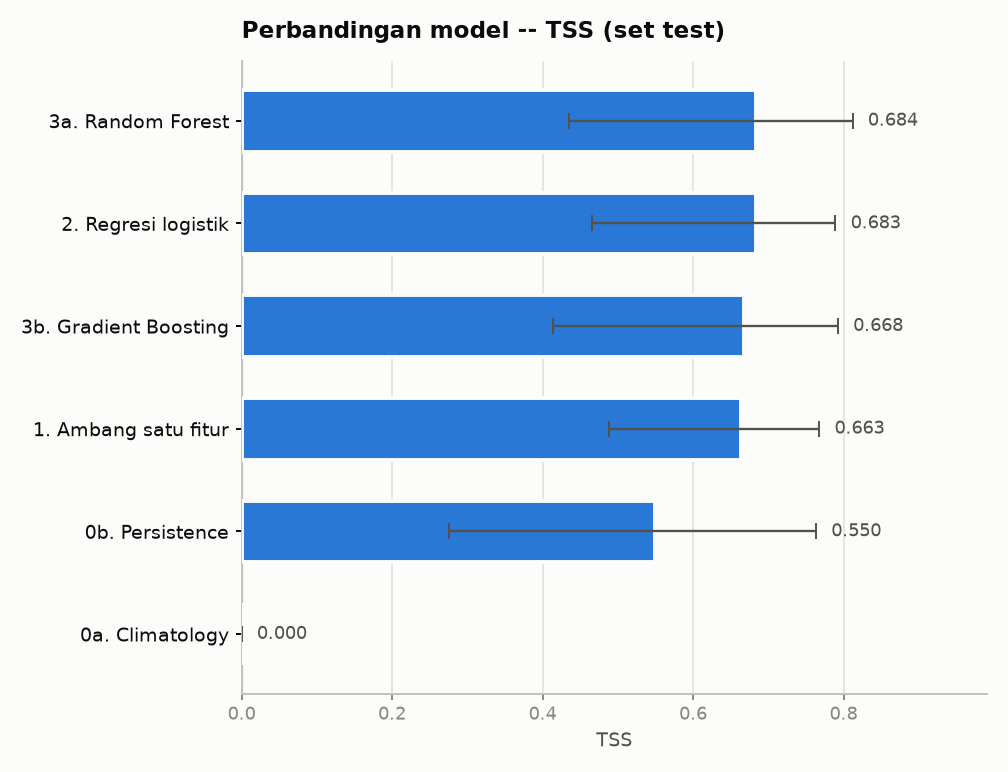

In [11]:
fig = cfg.figures_dir
best = table.sort_values("TSS", ascending=False).iloc[0]

ev.plot_model_comparison(table, fig / "model_comparison_tss.png", "TSS")
display(Image(filename=str(fig / "model_comparison_tss.png")))

#### Grafik 1 — Perbandingan TSS antar model

**Yang digambar.** Tiap batang adalah satu model, panjangnya TSS di data uji.
Garis melintang di ujung batang adalah selang kepercayaan 95%.

**Cara membacanya.** Jangan lihat urutan batangnya lebih dulu, lihat garis
selangnya. Kalau selang dua model bertumpang tindih, urutan mereka tidak punya
makna statistik.

**Yang terlihat di data ini.** Empat model teratas berkumpul di sekitar 0,66
sampai 0,68 dan selang kepercayaannya saling menutupi hampir sepenuhnya. Random
Forest kebetulan di atas regresi logistik pada eksekusi ini, tapi selisih 0,001
itu jauh lebih kecil daripada lebar selangnya sendiri yang sekitar 0,35.

**Kesimpulan yang boleh diambil, cuma dua:**

1. Semua model **belajar sesuatu**, karena semuanya jauh di atas Climatology.
2. Persistence di 0,55 **sudah cukup dekat** dengan kelompok teratas, padahal
   aturannya cuma "AR yang baru saja flare akan flare lagi", tanpa satu pun
   parameter yang dilatih.

**Catatan.** Climatology tidak punya garis selang karena TSS-nya nol persis
menurut definisi, bukan karena selangnya kebetulan sempit.

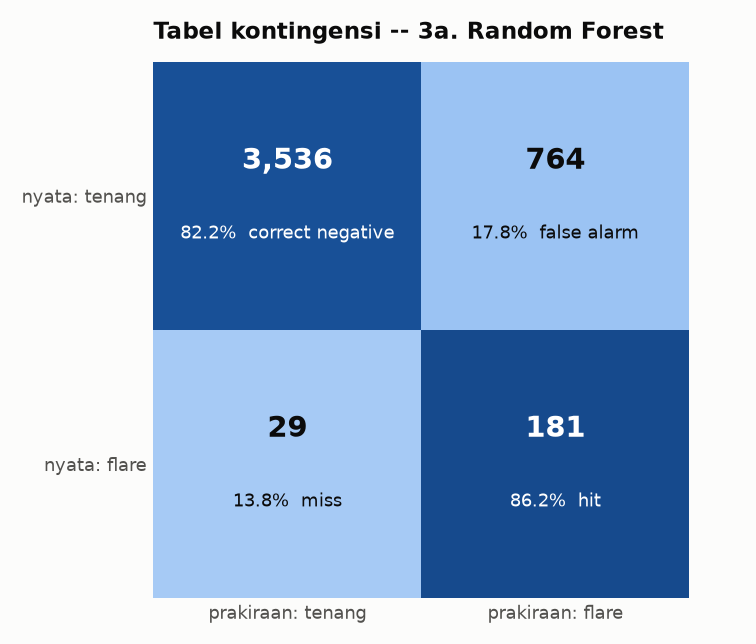

In [12]:
ev.plot_confusion(best.to_dict(), fig / "confusion_best.png")
display(Image(filename=str(fig / "confusion_best.png")))

#### Grafik 2 — Tabel kontingensi model terbaik

**Yang digambar.** Kotak 2×2 yang memecah 4.510 baris data uji menjadi empat
sel. Kolom adalah apa yang **diprakirakan** model, baris adalah apa yang
**benar-benar terjadi**. Angka besar adalah jumlah baris, persentase di bawahnya
dihitung per baris tabel, jadi relatif terhadap kenyataan.

**Cara membacanya.** Diagonal dari kiri atas ke kanan bawah adalah tebakan yang
benar, dua sel sisanya adalah dua jenis kesalahan yang berbeda harganya.

**Yang terlihat di data ini.**

- Dari **210 flare** yang benar-benar terjadi, **181 tertangkap** dan **29
  terlewat**. POD-nya 86,2%, dan kedengarannya bagus.
- Baris atas menceritakan harganya: ada **764 peringatan palsu** dari 4.300 baris
  yang sebenarnya tenang.
- Jadi model mengeluarkan **945 peringatan untuk 210 flare**, sekitar empat
  setengah kali lipat.

**Kenapa begitu.** Ketimpangan itu bukan cacat model, melainkan akibat langsung
dari cara ambangnya dipilih. Ambang di sini dioptimalkan untuk TSS, dan TSS
hampir tidak peduli pada false alarm karena pembaginya 4.300 baris tenang.
Menambah 764 peringatan palsu cuma menggeser POFD ke 0,18.

**Kalau dipakai betulan.** Seorang operator yang menerima 945 peringatan untuk
210 kejadian nyata akan berhenti mempercayai sistemnya. Kalau jumlah peringatan
yang wajar lebih penting daripada TSS tertinggi, ambangnya perlu dioptimalkan
terhadap HSS.

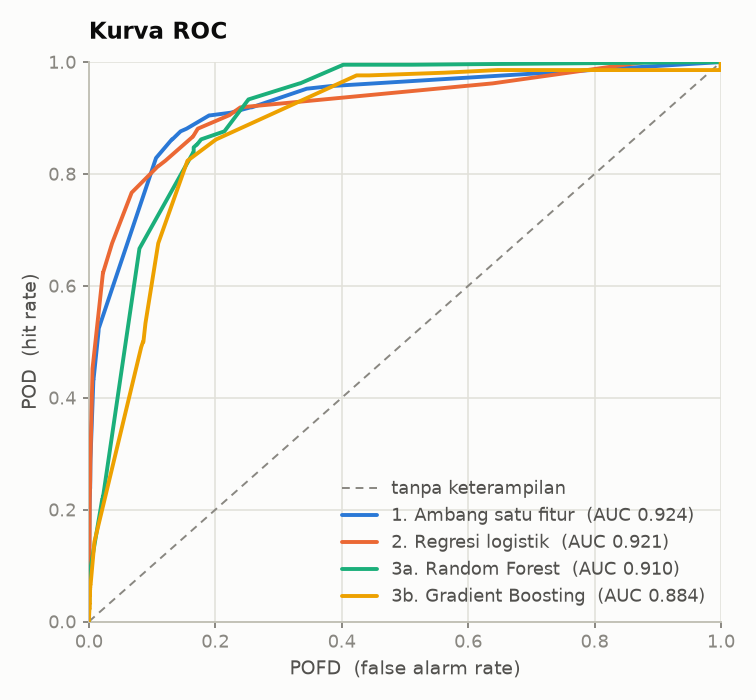

In [13]:
curves = {k: (yte, v) for k, v in probs.items() if not k.startswith(("0a", "0b"))}
ev.plot_roc(curves, fig / "roc_curves.png")
display(Image(filename=str(fig / "roc_curves.png")))

#### Grafik 3 — Kurva ROC

**Yang digambar.** Sumbu tegak POD, porsi flare yang tertangkap. Sumbu datar
POFD, porsi baris tenang yang salah diberi peringatan. Tiap kurva menelusuri
apa yang terjadi kalau ambangnya digeser dari 1 ke 0.

**Cara membacanya.** Garis putus-putus diagonal adalah model yang menebak asal.
Makin dekat kurva ke pojok kiri atas makin baik. AUC di legenda adalah luas di
bawah kurva, yaitu peluang model memberi skor lebih tinggi pada baris yang
memang flare dibanding baris tenang yang diambil acak.

**Yang terlihat di data ini.** Keempat kurvanya berdempetan dengan AUC 0,884
sampai 0,924. Dilihat dari grafik ini saja, keempat model terlihat hampir setara
dan semuanya terlihat sangat bagus.

**Kesan itu perlu ditahan.** ROC melebih-lebihkan pada data setimpang, dan
penyebabnya ada di sumbu datar. POFD dibagi jumlah baris tenang yang di sini
4.300 buah, jadi ratusan peringatan palsu cuma menggeser kurva sedikit ke kanan.
Grafik berikutnya memakai sumbu yang tidak memaafkan hal itu.

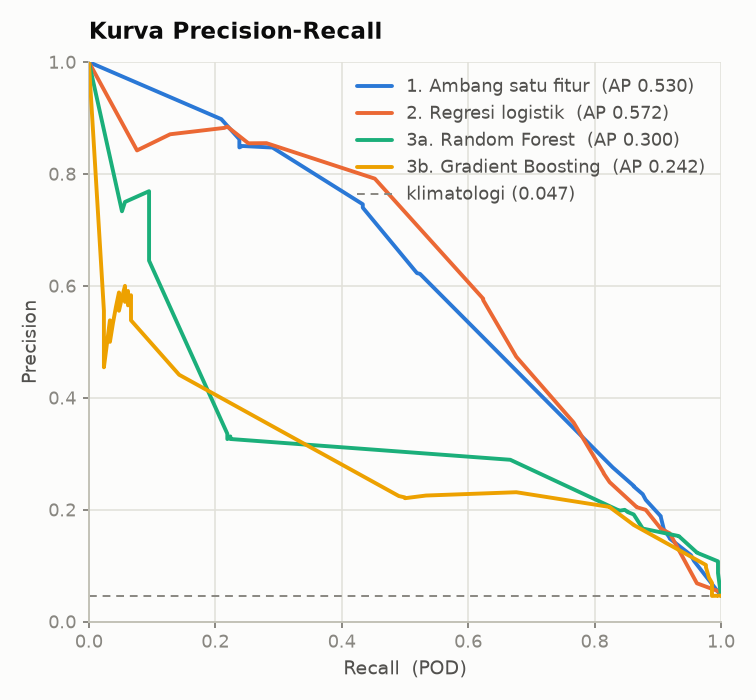

In [14]:
ev.plot_pr(curves, fig / "pr_curves.png")
display(Image(filename=str(fig / "pr_curves.png")))

#### Grafik 4 — Kurva Precision-Recall

**Yang digambar.** Sumbu datar tetap recall (sama dengan POD), tapi sumbu
tegaknya berganti jadi **precision**, yaitu porsi peringatan yang ternyata
benar. Pembaginya sekarang **jumlah peringatan yang dikeluarkan model**, bukan
jumlah baris tenang, dan di situlah perbedaannya muncul.

**Cara membacanya.** Garis putus-putus mendatar di 0,047 adalah lantai
klimatologi, tempat model yang menebak asal akan berada. Makin dekat ke pojok
kanan atas makin baik. AP di legenda adalah rata-rata precision di seluruh
rentang recall.

**Yang terlihat di data ini — urutannya berubah total dibanding ROC.**

| Model | ROC-AUC | AP (PR) |
|---|---|---|
| Regresi logistik | 0,921 | **0,572** |
| Ambang satu fitur | 0,924 | 0,530 |
| Random Forest | 0,910 | 0,300 |
| Gradient Boosting | 0,884 | 0,242 |

Random Forest punya ROC-AUC lebih tinggi daripada Gradient Boosting, tapi di PR
keduanya sama-sama jatuh jauh di bawah regresi logistik.

**Kesimpulannya.** Tiga metrik memberi tiga urutan berbeda untuk data yang sama:
TSS menempatkan Random Forest di atas, ROC menempatkan ambang satu fitur di
atas, dan PR menempatkan regresi logistik di atas.

Ini bukan tanda ada yang salah hitung. Ketiganya memang mengukur hal yang
berbeda, dan itu sebabnya **satu angka tunggal tidak pernah cukup** untuk
menyimpulkan model mana yang terbaik.

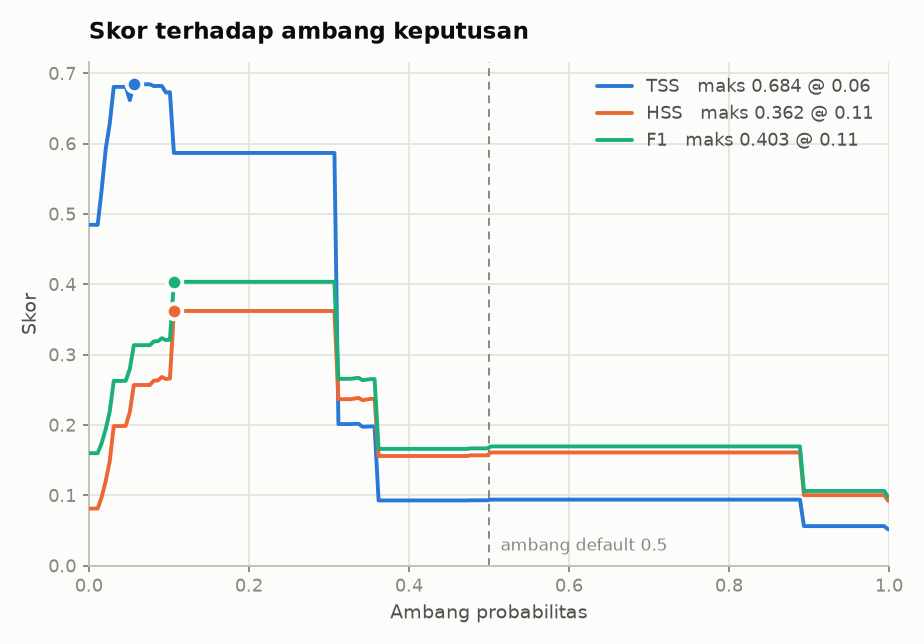

In [15]:
ev.plot_threshold_sweep(yte, probs[best["model"]], fig / "threshold_sweep.png")
display(Image(filename=str(fig / "threshold_sweep.png")))

#### Grafik 5 — Skor terhadap ambang keputusan

**Yang digambar.** Sumbu datar adalah ambang probabilitas, yaitu angka batas
untuk mengubah probabilitas jadi keputusan ya atau tidak. Sumbu tegak adalah
skor. Tiga garis untuk TSS, HSS, dan F1, masing-masing dengan titik bulat di
puncaknya.

**Cara membacanya.** Cari puncak tiap garis. Garis putus-putus tegak di 0,5
adalah ambang default yang dipakai hampir semua pustaka machine learning.

**Yang terlihat di data ini.**

- Ambang 0,5 memberi TSS sekitar **0,09**, padahal puncaknya **0,684 di ambang
  0,06**. Memakai ambang default saja sudah membuang hampir seluruh kemampuan
  model. Ini pelajaran terpenting dari grafik ini.
- Puncak ketiga metriknya tidak berada di tempat yang sama. TSS memuncak di
  0,06, sementara HSS dan F1 sama-sama memuncak di 0,11.

**Selisih puncak itu persis ketimpangan peringatan yang terlihat di grafik 2.**
Ambang yang lebih rendah menangkap lebih banyak flare dan sekaligus mengeluarkan
lebih banyak peringatan palsu. TSS senang, HSS tidak.

**Peringatan penting.** Ambang yang dipakai di notebook ini dipilih dari **data
validasi**, bukan dari grafik ini. Grafik ini memakai **data uji**, jadi hanya
untuk dilihat sesudahnya. Memilih ambang dari sini sama saja dengan mengintip
jawaban, dan skor yang dihasilkan tidak lagi jujur.

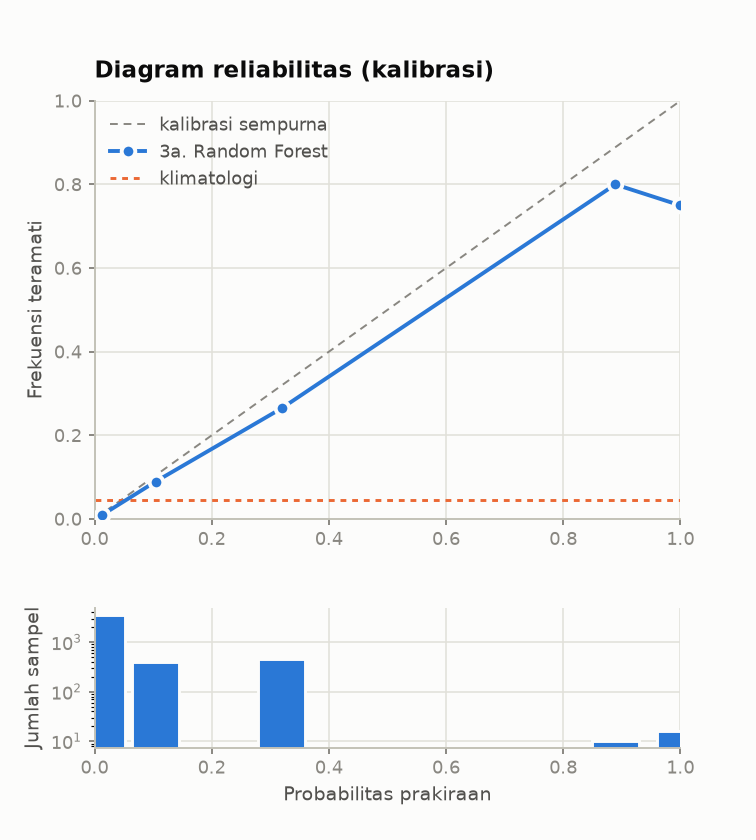

In [16]:
ev.plot_reliability(yte, probs[best["model"]], fig / "reliability.png",
                   name=best["model"])
display(Image(filename=str(fig / "reliability.png")))

#### Grafik 6 — Diagram reliabilitas

**Yang digambar, panel atas.** Prakiraan dikelompokkan menurut probabilitasnya.
Untuk tiap kelompok, sumbu datar adalah rata-rata probabilitas yang dikeluarkan
model, dan sumbu tegak adalah porsi yang benar-benar terjadi.

**Cara membacanya.** Kalau modelnya terkalibrasi, titik-titiknya jatuh di garis
diagonal: yang disebut "berpeluang 30%" memang terjadi pada 30% kasus. Titik di
**bawah** diagonal berarti model terlalu berani, titik di **atas** berarti
terlalu hati-hati.

**Yang terlihat di data ini.** Titiknya mengikuti diagonal cukup rapat sampai
sekitar 0,9, lalu berada sedikit di bawahnya. Artinya model agak terlalu berani
di ujung atas: kejadian yang ia sebut berpeluang 90% ternyata terjadi sekitar
75% sampai 80%.

**Panel bawah jauh lebih penting daripada kelihatannya.** Isinya jumlah baris di
tiap kelompok, dengan sumbu logaritmik. Batang pertama hampir 3.000 baris
sementara batang di sebelah kanan cuma belasan.

Jadi ujung kanan kurva di panel atas bersandar pada **sangat sedikit sampel** dan
tidak boleh dibaca terlalu serius. Kelompok yang isinya kurang dari lima baris
malah tidak digambar sama sekali.

**Kenapa grafik ini baru punya arti sekarang.** Karena probabilitasnya sudah
dikalibrasi di bagian 5. Tanpa kalibrasi isotonik, `class_weight="balanced"`
menggeser keluaran model sehingga angkanya tidak lagi berarti peluang, dan
titik-titiknya akan melenceng jauh dari diagonal.

---
## 8. Fitur mana yang paling berpengaruh

**Tujuan bagian ini:** menengok ke dalam model. Kalau dua model punya skor
mirip, cara mereka sampai ke skor itu masih bisa berbeda jauh, dan perbedaannya
kadang lebih informatif daripada skornya sendiri.

**Sel di bawah akan:** menggambar grafik kepentingan fitur untuk tiap model yang
menyediakannya, yaitu regresi logistik dan Random Forest.

### Kenapa koefisiennya bisa langsung dibandingkan

Sebelum masuk ke regresi logistik, tiap fitur dilewatkan `SignedLog` lalu
`StandardScaler`. Artinya semua fitur berakhir pada skala yang sama, sehingga
besar koefisiennya bisa langsung dibandingkan satu sama lain.

Tanda koefisiennya menunjukkan arah pengaruh: positif berarti nilai fitur yang
lebih besar menaikkan peluang flare.

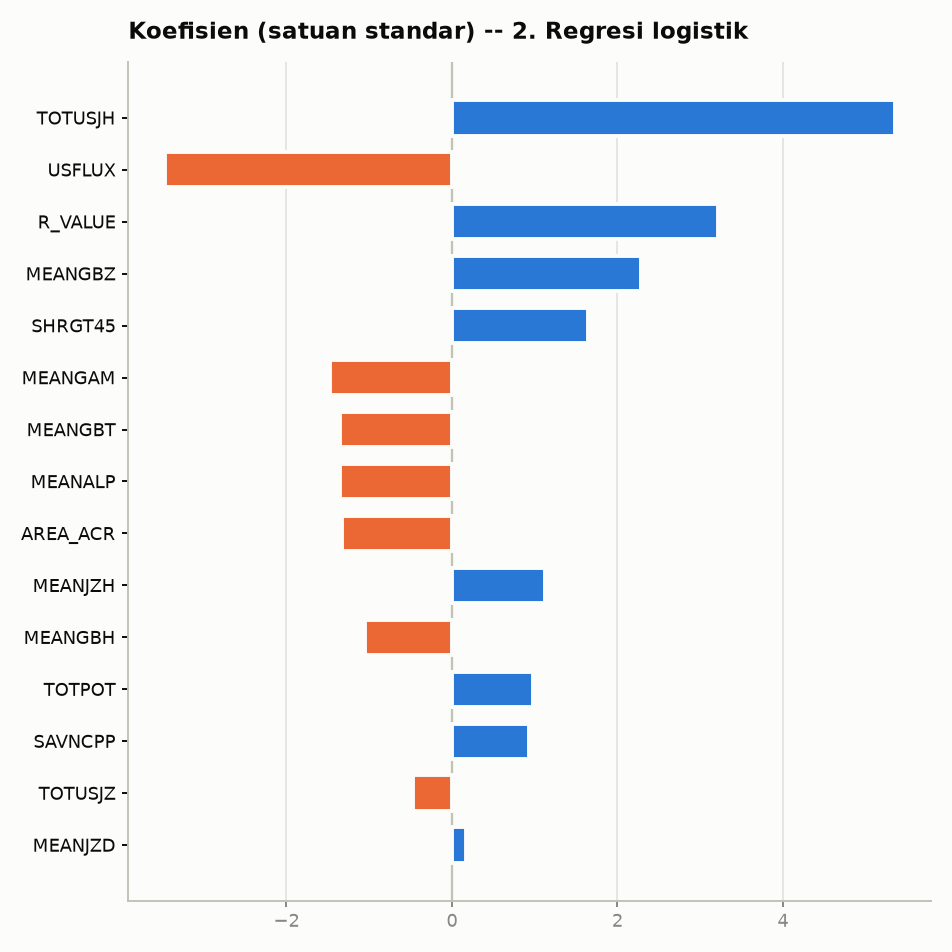

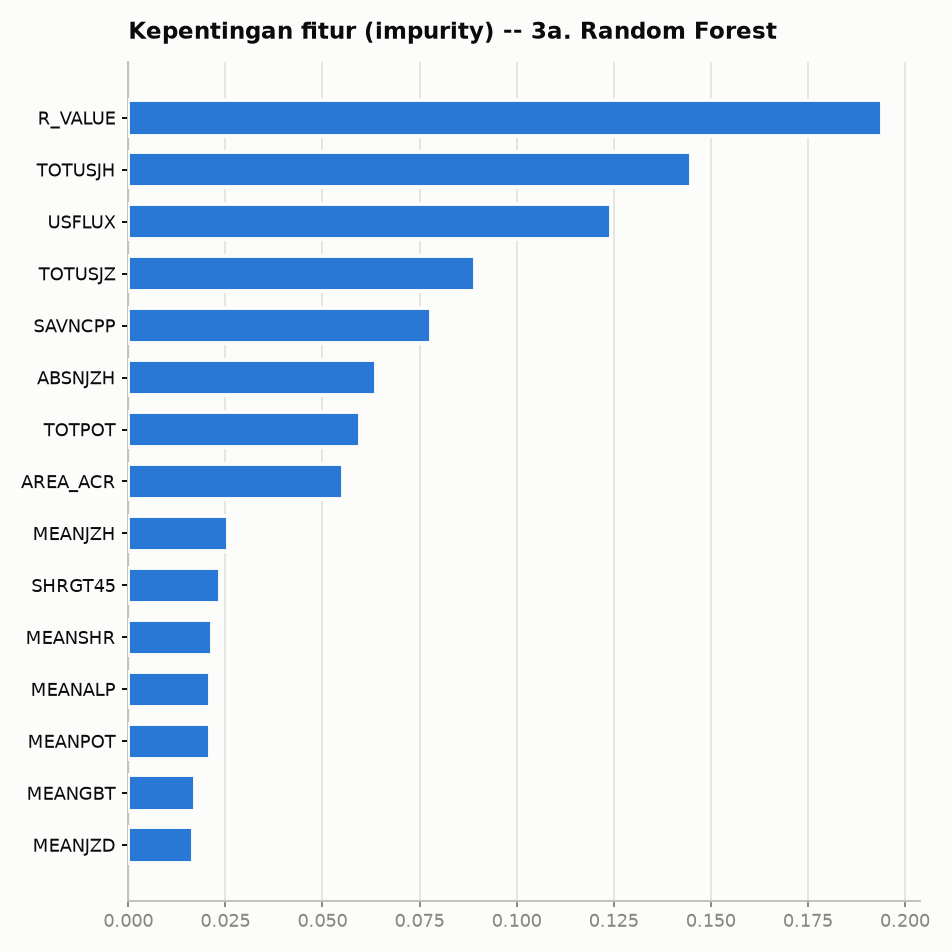

In [17]:
from flare_pipeline.models import unwrap

for name, model in fitted.items():
    if isinstance(unwrap(model), SingleFeatureThreshold):
        continue
    vals, label = extract_importance(model, feats)
    if np.any(vals):
        path = fig / f"importance_{name.split('. ')[-1].replace(' ', '_').lower()}.png"
        ev.plot_feature_importance(feats, vals, path, title=f"{label} -- {name}")
        display(Image(filename=str(path)))

### Membaca dua grafik di atas

#### Grafik 7 — Koefisien regresi logistik

**Yang digambar.** Tiap batang satu fitur. Panjang batang menunjukkan besar
pengaruh dalam satuan standar, warnanya menunjukkan arah: biru menaikkan peluang
flare, oranye menurunkan.

**Ada satu hal yang kelihatan janggal.** `USFLUX`, total fluks magnet tak
bertanda, punya koefisien **negatif** besar. Dibaca apa adanya, itu berarti makin
banyak fluks magnet makin kecil peluang flare, yang bertentangan dengan fisika
dan dengan seluruh literatur.

**Penjelasannya bukan fisika melainkan kolinearitas.** Korelasi antara `TOTUSJH`
dan `USFLUX` setelah diambil logaritma mencapai **0,979**, praktis dua nama untuk
informasi yang sama. Kalau dua kolom hampir identik, regresi bebas membagi
pengaruhnya dengan cara apa pun asalkan jumlahnya benar, termasuk memberi yang
satu koefisien positif besar dan yang lain negatif besar.

**Pelajarannya:** koefisien tunggal dari model yang kolinear tidak bisa dibaca
sebagai pengaruh fisis.

#### Grafik 8 — Kepentingan fitur Random Forest

**Yang digambar.** Tiap batang satu fitur, panjangnya seberapa besar fitur itu
menurunkan impurity di seluruh pohon. Di sini **tidak ada arah, hanya besar**,
karena ukuran impurity memang tidak mengenal tanda.

**Urutannya berbeda dari grafik sebelumnya:** `R_VALUE` paling atas, disusul
`TOTUSJH` lalu `USFLUX`.

**Yang menarik,** `USFLUX` justru masuk tiga besar sebagai kolom yang berguna,
padahal di grafik 7 koefisiennya membuatnya terlihat merugikan. Data dan
fiturnya sama persis untuk kedua grafik. Yang berbeda cuma cara kedua model
memperlakukan kolom yang saling berkorelasi: regresi **harus** memberi satu angka
per kolom, sedangkan pohon bisa memakai salah satu dari dua kolom kembar itu
bergantian tanpa harus memilih.

**`R_VALUE` di posisi teratas masuk akal secara fisis.** Nilai itu mengukur fluks
di sekitar garis pembalikan polaritas, tempat rekoneksi magnetik biasanya
bermula.

**Satu peringatan untuk grafik 8.** Kepentingan berbasis impurity cenderung
berpihak pada fitur yang nilainya banyak variasi, dan tidak tahu-menahu soal
metrik yang kita pakai. Ukuran yang lebih jujur ada di
`models.permutation_importance_tss`, yang mengukur seberapa besar TSS turun
kalau satu kolom diacak.

---
## 9. Tingkat 4: CNN di atas piksel magnetogram

**Tujuan bagian ini:** menguji apakah ringkasan buatan manusia sudah menangkap
semua yang penting, atau masih ada sisa informasi di dalam citranya.

Semua model di atas memakai 18 keyword SHARP. Angka-angka itu bukan data mentah:
JSOC menghitungnya dari magnetogram yang sama memakai rumus yang dirancang
manusia. Jadi tingkat 0 sampai 3 sebenarnya sedang menjawab **seberapa jauh
ringkasan buatan manusia bisa membawa kita**.

Tingkat 4 menanyakan hal lain: **adakah informasi di dalam piksel yang tidak
tertangkap oleh 18 angka itu?**

### Dua kandidat informasi yang hilang saat diringkas

**Pertama, bentuk dan ketajaman PIL** (garis pembalikan polaritas), yaitu batas
tempat medan magnet berbalik arah. `R_VALUE` meringkasnya jadi satu angka, dan
satu angka tidak bisa membedakan PIL panjang yang landai dari PIL pendek yang
sangat tajam.

**Kedua, tata letak fluks di dalam kotak AR.** Dua wilayah aktif dengan `USFLUX`
persis sama bisa punya susunan yang sama sekali berbeda.

CNN bisa mempelajari keduanya langsung dari citra, setidaknya secara prinsip.

### Tiga hal yang membuat tingkat 4 jauh lebih mahal

**1. Ukuran datanya berbeda jauh.** Satu cutout magnetogram sekitar 0,6 MB,
sedangkan seluruh keyword SHARP untuk dua tahun cuma beberapa MB.

**2. Jumlah kejadian positifnya tidak ikut bertambah.** Mengunduh lebih banyak
citra tidak menambah jumlah flare kelas M yang pernah terjadi. CNN di sini punya
ratusan ribu parameter untuk dipelajari dari beberapa ratus kejadian positif
saja.

**3. Perbandingannya gampang menjadi tidak sah.** Kalau CNN dinilai pada baris
yang kebetulan citranya sudah diunduh sementara Random Forest dinilai pada
seluruh baris, kedua angka TSS itu tidak bisa disandingkan. Masalah ini yang
paling berbahaya karena **tidak menimbulkan error**. Angkanya tetap keluar,
terlihat wajar, dan salah. Penangkalnya ada di sel `restrict_to_cache` nanti.

Bagian ini butuh PyTorch, yang sengaja tidak masuk `requirements.txt` karena
tingkat 0 sampai 3 tidak memerlukannya:

```
pip install torch --index-url https://download.pytorch.org/whl/cpu
```

In [18]:
from flare_pipeline import cnn as C

PATCH_SIZE = (128, 256)
N_AR       = 40    # jumlah wilayah aktif yang citranya dipakai
FRAMES     = 24    # frame berurutan per AR

# Pilih beberapa AR utuh dengan frame berurutan, bukan frame tunggal yang
# tersebar. Alasannya ada di sel penjelasan di bawah.
subset = C.select_ar_blocks(df, cfg, n_ars=N_AR, max_frames_per_ar=FRAMES)

kurang = C.missing_patches(subset, cfg)
print(f"{len(kurang):,} citra belum ada di disk.")

# Kalau masih ada yang kurang, buka komentar dua baris berikut. Butuh jaringan,
# dan perkiraan waktunya sekitar satu menit per AR.
# from flare_pipeline.magnetogram import download_patches
# download_patches(kurang, cfg)

[CNN] Blok AR: 956 frame dari 40 AR (24 pernah flare, 16 tidak) | 203 frame positif | ~574 MB unduhan.
[CNN] Perkiraan 40 permintaan ekspor JSOC (vs ~956 kalau frame-nya tersebar).
0 citra belum ada di disk.


### Kenapa memilih AR utuh, bukan frame yang tersebar

Pilihan ini kelihatannya soal selera, padahal menentukan apakah unduhannya
selesai dalam satu jam atau satu hari penuh.

**Soal kecepatan.** JSOC cuma mengizinkan satu permintaan ekspor tertunda per
akun, dan tiap permintaan butuh sekitar satu menit untuk diproses. Jadi yang
menentukan lama unduhan adalah **jumlah permintaan**, bukan jumlah berkas.

Frame yang tersebar di ratusan AR berarti ratusan permintaan, karena tiap frame
harus diminta sendiri-sendiri. Frame berurutan dari satu AR bisa diminta
sekaligus dalam satu spesifikasi rentang waktu. Dengan jumlah berkas yang sama,
40 AR cukup sekitar 40 permintaan.

**Untungnya di sisi data.** Frame berurutan memperlihatkan evolusi AR, sesuatu
yang tidak bisa dilihat dari potret tunggal. AR yang sedang tumbuh dan AR yang
sedang meluruh bisa punya nilai SHARP mirip tapi peluang flare berbeda.

**Ruginya.** Jumlah AR yang dilihat model jadi sedikit, dan keragaman AR itulah
yang paling menentukan apakah model bisa digeneralisasi.

Jadi ini pertukaran, bukan perbaikan gratis. Kalau waktunya ada, naikkan `N_AR`
lebih dulu sebelum menaikkan `FRAMES`.

### Cache piksel

**Tujuan sel berikutnya:** mengubah kumpulan berkas FITS jadi satu berkas biner
yang cepat dibaca, supaya pelatihan tidak habis waktu di disk.

Membaca berkas FITS jauh lebih lambat daripada membaca memmap. Kalau tiap epoch
membuka ulang FITS-nya, waktu latih akan habis di baca-tulis disk, bukan di
hitungan.

`build_patch_cache` mengubah semua citra sekali saja menjadi satu berkas biner
float16 berukuran seragam, disertai indeks dari pasangan `(HARPNUM, T_REC)` ke
nomor baris. Cache-nya bisa ditambah tanpa dibangun ulang, jadi menambah citra
baru tidak perlu mengulang dari nol.

### Kenapa normalisasinya pakai arcsinh

Nilai piksel Bz dinormalkan dengan `arcsinh(Bz/50)`, bukan dibagi angka tetap.

Bz membentang dari sekitar 10 gauss di medan tenang sampai 3.000 gauss di umbra.
Pembagian biasa akan menekan seluruh struktur lemah di sekitar PIL jadi hampir
nol, padahal justru di situ fisikanya.

Fungsi arcsinh bersifat **linear di bawah 50 gauss** dan **logaritmik di
atasnya**, jadi struktur lemahnya selamat sementara umbra yang sangat kuat tidak
mendominasi. Yang tidak kalah penting, fungsi itu **mempertahankan tanda**, dan
tanda adalah polaritas, inti dari fisika PIL.

In [19]:
cache = C.build_patch_cache(subset, cfg, size=PATCH_SIZE)
print("cache:", cache.shape)

[CNN] Cache piksel sudah lengkap: 993 citra @ 128x256 (patches_128x256.f16).
cache: (993, 128, 256)


### Menyamakan baris untuk semua tingkat

**Langkah ini yang menentukan sah atau tidaknya seluruh perbandingan di bawah.**
Ini penangkal masalah nomor 3 yang disebut di awal bagian 9.

`restrict_to_cache` memangkas data latih, validasi, dan uji ke baris yang punya
citra, dan pemangkasannya berlaku untuk **semua tingkat sekaligus**, bukan cuma
untuk CNN. Sesudah ini tingkat 0 sampai 4 dinilai pada baris yang persis sama,
sehingga selisih TSS-nya benar-benar mencerminkan selisih kemampuan model.

**Porsi positif sesudah pemangkasan akan jauh lebih tinggi daripada aslinya,**
sekitar 20% dibanding 4%. Itu wajar, karena `select_ar_blocks` sengaja
memperbanyak AR yang pernah flare. Yang penting semua model melihat komposisi
yang sama.

**Satu akibatnya perlu diingat waktu membaca hasil.** Angka di bagian ini
**tidak bisa** dibandingkan dengan angka di bagian 6, karena data ujinya berbeda
jumlah maupun komposisinya. Data uji di bagian 6 berisi 4.510 baris dengan basis
rate 4,66%; di sini cuma 117 baris dengan basis rate 20,5%.

In [20]:
splits_img = C.restrict_to_cache(splits, cache)
train_i, val_i, test_i = splits_img["train"], splits_img["val"], splits_img["test"]

for nama, part in splits_img.items():
    assert len(part) and part["y"].sum(), f"set {nama} tidak punya positif — perbesar subset"


[CNN] Membatasi seluruh tangga model ke baris yang punya citra:
      train   11,125 ->     432 sampel | positif 20.14%, 18 HARP
      val      5,604 ->     444 sampel | positif 21.17%, 23 HARP
      test     4,510 ->     117 sampel | positif 20.51%, 6 HARP



### Melatih CNN

**Tujuan sel berikutnya:** melatih CNN kecil di atas piksel, lalu menilainya
dengan prosedur yang persis sama seperti model lain.

### Kenapa arsitekturnya sengaja dibuat kecil

Empat blok konvolusi, pooling global, lalu satu kepala linear. Jaringan sebesar
ResNet-50 pada data sesedikit ini akan menghafal data latih dalam beberapa epoch
dan tidak bisa menggeneralisasi sama sekali.

**Pooling globalnya memakai rata-rata dan maksimum sekaligus,** lalu keduanya
digabung. Rata-rata menangkap seberapa kuat AR secara keseluruhan, maksimum
menangkap ada tidaknya satu titik yang sangat tajam, dan PIL curam justru muncul
di yang kedua. Pooling global juga membuat jaringan tidak peduli di sebelah mana
AR-nya berada di dalam kotak.

**Ketimpangan kelas ditangani lewat `pos_weight` pada loss,** bukan dengan
menggandakan sampel positif. Citra positif di data ini nyaris identik dari jam
ke jam, jadi menggandakannya cuma menambah peluang menghafal tanpa menambah
informasi.

**Early stopping memantau potongan terakhir data latih menurut urutan waktu,**
bukan potongan acak. Potongan acak akan bocor, karena sampel AR yang sama pada
jam berdekatan hampir identik, dan sinyal berhentinya jadi terlalu optimistis.
Potongan ini juga sengaja berbeda dari `val_cal` dan `val_thr` yang sudah
terpakai untuk kalibrasi dan pemilihan ambang.

In [21]:
# Ulangi langkah 5 pada baris yang sudah disamakan, supaya tingkat 0-3 dan
# tingkat 4 benar-benar dinilai pada data yang identik.
val_sorted_i = val_i.sort_values("T_REC")
cut_i = len(val_sorted_i) // 2
val_cal_i, val_thr_i = val_sorted_i.iloc[:cut_i], val_sorted_i.iloc[cut_i:]

ytr_i, yte_i = train_i["y"].values, test_i["y"].values
groups_te_i  = test_i["HARPNUM"].values
clim_i       = float(ytr_i.mean())
reports_i, probs_i, fitted_i = [], {}, {}

def assess_img(model, name, cols, calibrate=True):
    """Sama persis dengan `assess`, hanya kolomnya bisa berbeda per model."""
    if calibrate:
        model = ProbabilityCalibrator(model).fit(val_cal_i[cols], val_cal_i["y"].values)
    thr, tss_va = ev.best_threshold(val_thr_i["y"].values,
                                    model.predict_proba(val_thr_i[cols])[:, 1], "TSS")
    p_te = model.predict_proba(test_i[cols])[:, 1]
    rep = ev.evaluate(yte_i, p_te, thr, groups_te_i, name, clim_i)
    reports_i.append(rep); probs_i[name] = p_te; fitted_i[name] = model
    print(f"[{name}] ambang {thr:.3f} (TSS validasi {tss_va:+.4f})")
    ev.print_report(rep)
    return rep

# --- pembanding: tingkat 0b dan 3a pada baris yang sama ---
pers_i = PersistenceBaseline()
p_pers = pers_i.predict_proba(test_i["y_persistence"].values)[:, 1]
rep = ev.evaluate(yte_i, p_pers, 0.5, groups_te_i, pers_i.name, clim_i)
reports_i.append(rep); probs_i[pers_i.name] = p_pers; ev.print_report(rep)

rf_i = MODEL_FACTORY["3a. Random Forest"](cfg.random_state).fit(train_i[feats], ytr_i)
assess_img(rf_i, "3a. Random Forest", feats)


  0b. Persistence   (ambang = 0.500, N = 117)
  Tabel kontingensi   hit=16     miss=8      false alarm=11      correct neg=82
  ----------------------------------------------------------------
  TSS (utama)      +0.5484  [+0.000, +0.745]
  HSS              +0.5241  [+0.000, +0.729]
  GSS / ETS        +0.3551
  MCC              +0.5256
  ----------------------------------------------------------------
  POD (recall)     0.6667      POFD  0.1183
  Precision        0.5926      FAR   0.4074
  F1               0.6275      CSI   0.4571
  Frequency bias   1.1250  (1.0 = jumlah peringatan pas)
  ----------------------------------------------------------------
  ROC-AUC          0.7742      PR-AUC  0.4634
  Brier            0.16239     BSS     +0.0041
  Accuracy         0.8376  (menyesatkan -- basis rate 20.51%)


[3a. Random Forest] ambang 0.001 (TSS validasi +0.4105)

  3a. Random Forest   (ambang = 0.001, N = 117)
  Tabel kontingensi   hit=24     miss=0      false alarm=64      correct neg=29
  ----------------------------------------------------------------
  TSS (utama)      +0.3118  [-0.691, +0.669]
  HSS              +0.1568  [+0.000, +0.559]
  GSS / ETS        +0.0850
  MCC              +0.2916
  ----------------------------------------------------------------
  POD (recall)     1.0000      POFD  0.6882
  Precision        0.2727      FAR   0.7273
  F1               0.4286      CSI   0.2727
  Frequency bias   3.6667  (1.0 = jumlah peringatan pas)
  ----------------------------------------------------------------
  ROC-AUC          0.9505      PR-AUC  0.7736
  Brier            0.08686     BSS     +0.4673
  Accuracy         0.4530  (menyesatkan -- basis rate 20.51%)


{'model': '3a. Random Forest',
 'threshold': 0.001,
 'TP': 24,
 'FP': 64,
 'FN': 0,
 'TN': 29,
 'N': 117,
 'base_rate': 0.20512820512820512,
 'POD': 1.0,
 'POFD': 0.6881720430107527,
 'FAR': 0.7272727272727273,
 'Precision': 0.2727272727272727,
 'Recall': 1.0,
 'Specificity': 0.3118279569892473,
 'F1': 0.42857142857142855,
 'CSI': 0.2727272727272727,
 'FrequencyBias': 3.6666666666666665,
 'TSS': 0.31182795698924726,
 'HSS': 0.15675675675675677,
 'GSS': 0.08504398826979472,
 'MCC': 0.2916230242449912,
 'Accuracy': 0.452991452991453,
 'ROC_AUC': 0.9504928315412186,
 'PR_AUC': 0.7736111111111111,
 'Brier': 0.08685870222846652,
 'BSS': 0.467335654336664,
 'Climatology': 0.2013888888888889,
 'TSS_lo': -0.6913147310206134,
 'TSS_hi': 0.6690768150388934,
 'HSS_lo': 0.0,
 'HSS_hi': 0.558991293905734}

In [22]:
# --- tingkat 4 ---
cnn_cols = C.cnn_columns(feats)          # HARPNUM + T_REC sebagai kunci citra
cnn = C.CNNClassifier(cache, epochs=30, batch_size=32, width=16,
                      random_state=cfg.random_state)
cnn.fit(train_i[cnn_cols], ytr_i)
print(cnn.describe())

assess_img(cnn, cnn.name, cnn_cols)


[CNN] 310,225 parameter | perangkat cpu | latih 367 (69 positif) | pantau 65 sampel [AP] | pos_weight 4.3
[CNN] PERINGATAN: kurang dari 100 sampel positif di set latih. Hasil CNN pada skala ini nyaris pasti didominasi overfitting; perbesar rentang data sebelum menyimpulkan apa pun.


[CNN]   epoch   1/30  loss 1.0963  AP +0.1863


[CNN]   epoch   5/30  loss 0.7968  AP +0.6771


[CNN]   epoch  10/30  loss 0.7534  AP +0.2792


[CNN]   epoch  15/30  loss 0.6285  AP +0.7428


[CNN]   early stopping di epoch 17 (AP terbaik +0.7885)
CNN 128x256 piksel; AP pantau terbaik +0.7885


[4. CNN magnetogram] ambang 0.001 (TSS validasi +0.2648)

  4. CNN magnetogram   (ambang = 0.001, N = 117)
  Tabel kontingensi   hit=24     miss=0      false alarm=43      correct neg=50
  ----------------------------------------------------------------
  TSS (utama)      +0.5376  [-0.369, +0.822]
  HSS              +0.3230  [+0.000, +0.678]
  GSS / ETS        +0.1926
  MCC              +0.4388
  ----------------------------------------------------------------
  POD (recall)     1.0000      POFD  0.4624
  Precision        0.3582      FAR   0.6418
  F1               0.5275      CSI   0.3582
  Frequency bias   2.7917  (1.0 = jumlah peringatan pas)
  ----------------------------------------------------------------
  ROC-AUC          0.7961      PR-AUC  0.3872
  Brier            0.12774     BSS     +0.2166
  Accuracy         0.6325  (menyesatkan -- basis rate 20.51%)


{'model': '4. CNN magnetogram',
 'threshold': 0.001,
 'TP': 24,
 'FP': 43,
 'FN': 0,
 'TN': 50,
 'N': 117,
 'base_rate': 0.20512820512820512,
 'POD': 1.0,
 'POFD': 0.46236559139784944,
 'FAR': 0.6417910447761194,
 'Precision': 0.35820895522388063,
 'Recall': 1.0,
 'Specificity': 0.5376344086021505,
 'F1': 0.5274725274725275,
 'CSI': 0.3582089552238806,
 'FrequencyBias': 2.7916666666666665,
 'TSS': 0.5376344086021505,
 'HSS': 0.3229713362939039,
 'GSS': 0.1925854597977853,
 'MCC': 0.43884559904114945,
 'Accuracy': 0.6324786324786325,
 'ROC_AUC': 0.7961469534050178,
 'PR_AUC': 0.3872085463187158,
 'Brier': 0.12773987597156672,
 'BSS': 0.2166302776371615,
 'Climatology': 0.2013888888888889,
 'TSS_lo': -0.3685144376899696,
 'TSS_hi': 0.8218440366972475,
 'HSS_lo': 0.0,
 'HSS_hi': 0.6778408802157195}

### Grafik 9 — Kurva latih CNN

Grafik di sel berikutnya lebih banyak bercerita daripada angka TSS mana pun di
bagian ini.

**Yang digambar.** Garis merah adalah loss di data latih, dibaca pada **sumbu
kiri**. Garis biru adalah skor pantau (AP) di potongan terakhir data latih,
dibaca pada **sumbu kanan**. Sumbu datar adalah nomor epoch.

**Cara membacanya.** Yang dicari **bukan** loss yang turun. Loss di data latih
hampir selalu turun, karena model memang dioptimalkan untuk itu. Yang dicari
adalah apakah **garis birunya ikut naik**.

| Pola | Artinya |
|---|---|
| Merah turun, biru naik | model benar-benar belajar |
| Merah turun, biru mendatar atau memburuk | model sedang menghafal |

**Yang terlihat di data ini.** Garis birunya naik turun tajam dari epoch ke
epoch: 0,19 di epoch 1, lalu 0,68, turun ke 0,28, naik lagi ke 0,74.

Itu bukan bug. Potongan pantaunya cuma 65 sampel, dan pada jumlah sebesar itu
satu dua sampel yang berubah tebakan sudah cukup menggeser skornya jauh.
Akibatnya early stopping bisa berhenti di sebuah lonjakan kebetulan, bukan di
puncak yang sebenarnya.

**Obatnya bukan mengubah arsitektur, melainkan menambah data.**

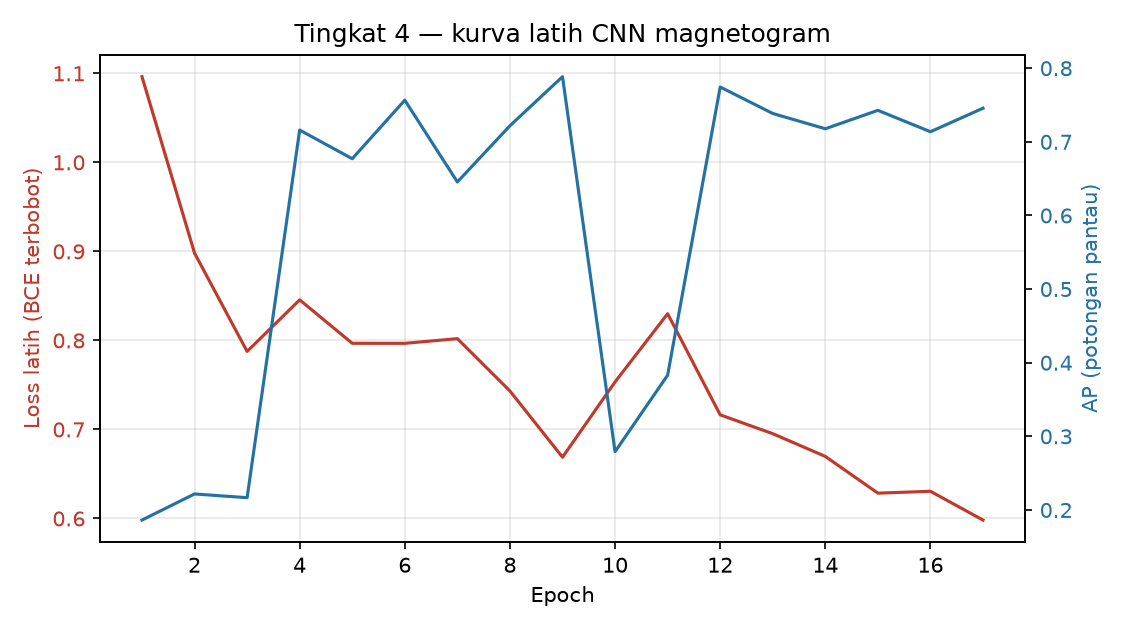

,epoch,loss,AP
7,8,0.743220,0.721853
8,9,0.668840,0.788505
9,10,0.753377,0.279209
10,11,0.830000,0.383052
11,12,0.716417,0.774443
12,13,0.695243,0.738506
13,14,0.669712,0.717738
14,15,0.628456,0.742783
15,16,0.630551,0.713717
16,17,0.598220,0.745687


In [23]:
path = C.plot_training_curve(cnn, cfg.figures_dir / "cnn" / "cnn_training_curve.png")
display(Image(filename=str(path)))
cnn.history_frame().tail(10)

### Perbandingan akhir

**Tujuan sel di bawah:** menyandingkan Persistence, Random Forest, dan CNN pada
baris uji yang **identik**.

Ini satu-satunya perbandingan di notebook ini yang boleh dibaca sebagai "model
mana yang lebih baik". Semua tabel sebelumnya membandingkan model pada populasi
data yang sama, tapi hanya di sini ketiga tingkat berbeda dinilai pada baris
yang sama persis.

Kolom `N` dan `base_rate` sengaja ikut ditampilkan supaya jelas bahwa angka di
sini berasal dari data uji yang berbeda dengan bagian 6.

In [24]:
tabel_i = ev.report_table(reports_i)
kolom = ["model", "TSS", "TSS_lo", "TSS_hi", "HSS", "POD", "FAR",
         "ROC_AUC", "PR_AUC", "BSS", "N", "base_rate"]
tabel_i[kolom].sort_values("TSS", ascending=False)

,model,TSS,TSS_lo,TSS_hi,HSS,POD,FAR,ROC_AUC,PR_AUC,BSS,N,base_rate
0,0b. Persistence,0.548387,0.000000,0.745249,0.524085,0.666667,0.407407,0.774194,0.463438,0.004118,117,0.205128
2,4. CNN magnetogram,0.537634,-0.368514,0.821844,0.322971,1.000000,0.641791,0.796147,0.387209,0.216630,117,0.205128
1,3a. Random Forest,0.311828,-0.691315,0.669077,0.156757,1.000000,0.727273,0.950493,0.773611,0.467336,117,0.205128


### Cara membaca hasil di atas dengan jujur

**Hal pertama yang perlu dilihat bukan urutan TSS-nya, melainkan lebar selang
kepercayaannya.**

| Model | TSS | Selang 95% |
|---|---|---|
| Persistence | 0,548 | [0,000 , 0,745] |
| CNN magnetogram | 0,538 | [−0,369 , 0,822] |
| Random Forest | 0,312 | [−0,691 , 0,669] |

Ketiga selang itu saling menutupi hampir seluruhnya, dan dua di antaranya
bahkan mencakup nol. **Kesimpulan yang benar adalah: belum ada bukti CNN lebih
baik atau lebih buruk dari yang lain.** Dengan 117 baris uji dan 24 kejadian
positif, data ini memang tidak cukup untuk memisahkan model-model ini.

Perhatikan juga Random Forest yang POD-nya 1,0 tapi POFD 0,69: ambang yang
terpilih di data validasi kecil ternyata nyaris memberi peringatan untuk semua
baris. Itu gejala khas data validasi yang terlalu sedikit, bukan gejala model
yang buruk.

### Tiga kemungkinan hasil dan tafsirannya

**Kalau selangnya bertumpang tindih** (seperti sekarang): laporkan apa adanya
sebagai "belum bisa dibedakan". Jangan pilih pemenang.

**Kalau CNN kalah jauh:** tersangka pertamanya jumlah data, bukan arsitektur.
Menambah lapisan atau memperbesar `width` hampir pasti memperburuk, karena
masalahnya kelebihan kapasitas dan bukan kekurangan. Peringatan `kurang dari 100
sampel positif` yang tercetak waktu pelatihan sudah menandakan hal ini.

**Kalau CNN justru menang telak dengan TSS sangat tinggi:** curigai kebocoran
sebelum merayakan. Periksa apakah `restrict_to_cache` benar-benar dipanggil, dan
apakah ada HARP yang sama muncul di data latih sekaligus data uji dalam porsi
besar.

**Untuk hasil yang benar-benar layak dilaporkan,** yang dibutuhkan rentang 2010
sampai 2018 penuh lewat `Config()` dan jumlah AR yang jauh lebih banyak, bukan
arsitektur yang lebih rumit.

---
## 10. Yang bisa dikerjakan selanjutnya

Diurutkan dari yang paling murah dan paling besar pengaruhnya.

> Bagian 11 menjalankan saran 1-3 di bawah dan melaporkan hasilnya, termasuk
> satu premis di daftar ini yang ternyata keliru.


**1. Perpanjang rentang data.** Ganti `quick_config()` dengan `Config()` untuk
memakai rentang 2010 sampai 2018.

*Kenapa ini nomor satu:* dua tahun cuma memberi sekitar 200 kejadian positif di
data uji, dan selama selangnya masih selebar sekarang, hampir tidak ada
perbandingan model yang bisa disimpulkan.

> **Koreksi dari Bagian 11.** Memperpanjang rentang saja ternyata **tidak**
> menyempitkan selangnya. Dengan batas split yang lama, set uji jatuh di
> 2017-2018 (minimum matahari), jumlah positifnya justru turun ke 201, dan
> seluruhnya berasal dari 3 HARP saja — selangnya malah melebar ke ~0,99. Yang
> menentukan bukan jumlah baris maupun jumlah positif, melainkan **jumlah AR
> berflare yang berbeda di set uji**.
>
> Tiga hal yang akhirnya bekerja, semuanya di Bagian 11: rentangnya
> diperpanjang sampai **2025** supaya mencakup puncak siklus 25, batas split
> digeser agar set uji jatuh di fase aktif (2022-2025), dan evaluasinya memakai
> beberapa jendela walk-forward. Selang TSS turun dari ~0,99 ke ~0,065.

**2. Tambahkan fitur perubahan.** `add_temporal_features(df, cfg)` menghitung
selisih dan simpangan baku 24 jam untuk tiap HARP.

*Kenapa berguna:* snapshot tunggal tidak bisa membedakan AR yang sedang tumbuh
dari AR yang sedang meluruh, padahal peluang flare keduanya berbeda.

**3. Masukkan riwayat flare AR sebagai fitur** lewat
`feature_columns(..., include_history=True)`.

*Kenapa berguna:* ini pada dasarnya menyuntikkan kekuatan Persistence ke dalam
model ML. Mengingat Persistence sendiri sudah mencapai TSS 0,55, informasi itu
jelas bernilai.

**4. Bandingkan dengan SWAN-SF** ([DATA_GUIDE.md](DATA_GUIDE.md) §3a).

*Kenapa berguna:* supaya angkanya bisa disandingkan dengan hasil di makalah lain
yang memakai dataset benchmark yang sama.

**5. Perbanyak AR untuk tingkat 4.** Bagian 9 dijalankan pada beberapa puluh AR
saja. Naikkan `N_AR`, lalu unduh sisanya lewat `download_patches`.

*Kenapa `N_AR` dan bukan `FRAMES`:* yang kurang adalah keragaman wilayah aktif,
bukan jumlah frame per wilayah. Menambah frame dari AR yang sama hampir tidak
menambah informasi baru, karena frame berdekatan nyaris identik.

---
## 11. Model lanjutan: rentang 2010-2025

**Tujuan bagian ini:** mengerjakan saran 1-3 dari Bagian 10, lalu menguji
apakah saran itu benar-benar menolong. Pertanyaannya bukan "berapa TSS model
lanjutan", melainkan **"apakah tambahannya nyata, dan seberapa yakin kita?"**

Seluruh perhitungan di bagian ini dijalankan oleh
[run_advanced.py](run_advanced.py), bukan oleh notebook, karena melatih ulang
seluruh tangga model pada 417 ribu baris butuh berjam-jam. Sel-sel di bawah
hanya membaca berkas hasilnya dari `output_dataset/`.

```
python run_pipeline.py                                    # unduh + label (sekali)
python run_advanced.py --offline --walk-forward 5         # perbandingan lanjutan
```

### Datanya sekarang

`Config()` mencakup **2010-05 sampai 2025-12** pada cadence 1 jam — 188 bulan,
jadi dua siklus matahari sekaligus. Siklus 25 memuncak sekitar 2024 dan jauh
lebih produktif daripada akhir siklus 24: tahun 2024 saja menyumbang 946 flare
kelas M/X, sementara 2018 dan 2019 tidak punya satu pun.

| | |
|---|---|
| Baris SHARP mentah | 1.213.209 |
| Setelah quality control | **417.096** |
| Kejadian positif (>= M1.0 dalam 24 jam) | **21.727** (5,21%) |

Bandingkan dengan Bagian 1-9 yang memakai `quick_config()`: 21.239 baris dan
845 positif. Jadi datanya sekitar **20 kali lebih besar** dalam jumlah
kejadian positif.

### Tiga konfigurasi fitur yang dibandingkan

| Konfigurasi | Jumlah fitur | Isinya |
|---|---|---|
| **A. SHARP saja** | 18 | sama persis dengan tingkat 2-3 di Bagian 5 |
| **B. + temporal** | 54 | ditambah selisih dan simpangan baku 24 jam tiap fitur (saran #2) |
| **C. + riwayat** | 55 | ditambah `log_flux_obs`, riwayat flare AR itu sendiri (saran #3) |

Ketiganya dinilai pada **baris uji yang identik**, sehingga selisih skornya
murni berasal dari perbedaan fitur.

### Satu alat baru: bootstrap berpasangan

Bagian 9 buntu karena selang kepercayaan dua model saling menutupi, sehingga
tidak ada yang bisa disimpulkan. Masalahnya, sebagian besar ragam skor berasal
dari "kebetulan set uji ini berisi AR yang mana" — dan ragam itu **dialami
kedua model bersama-sama**.

Bootstrap berpasangan meresample HARP, lalu menghitung **selisihnya di dalam
resample yang sama**. Komponen ragam bersama itu saling meniadakan, sehingga
selang untuk selisih bisa jauh lebih sempit daripada selang masing-masing
model. Perbaikan nyata tetap terdeteksi walaupun dua selang marginalnya
bertumpang tindih hampir seluruhnya.

### Temuan 1: yang menentukan lebar selang adalah jumlah AR berflare

Saran #1 di Bagian 10 berbunyi: "dua tahun cuma memberi sekitar 200 kejadian
positif di data uji, dan itulah alasan selang kepercayaannya selebar sekarang."

Bagian pertama kalimat itu benar. Bagian keduanya **tidak lengkap**, dan sel
berikut menunjukkan kenapa.

In [1]:
import pandas as pd

diag = pd.read_csv("output_dataset/diagnosa_split.csv")
diag["positif_per_AR_berflare"] = (diag["positif"] / diag["harp_berflare"]).round(1)
diag

,setup,n_uji,positif,harp_uji,harp_berflare,positif_per_AR_berflare
0,"2013-2014, split tunggal (Bagian 1-9)",4510,210,90,11,19.1
1,"2010-2018, split tunggal (batas lama)",12145,201,82,3,67.0
2,"2010-2025, split tunggal (batas baru)",180092,14364,980,251,57.2
3,"2010-2025, walk-forward 4 jendela",179981,14349,997,253,56.7


### Membaca tabel di atas

Perhatikan kolom **`harp_berflare`** — berapa banyak wilayah aktif *berbeda*
yang benar-benar menghasilkan flare di set uji. Itulah ukuran sampel yang
sesungguhnya, karena blok bootstrap di notebook ini adalah HARP.

**Baris kedua adalah pelajarannya.** Memperpanjang rentang dari dua tahun ke
2010-2018 menambah data secara keseluruhan, tapi jumlah positif di set uji
justru **turun** dari 210 ke 201 — dan positif itu datang dari **3 HARP saja**,
bukan 11.

Penyebabnya siklus matahari. Batas split lama (`val_end="2016-06-30"`)
menempatkan set uji di 2017-2018, dasar minimum matahari. Hampir seluruh
positif di situ berasal dari AR 12673, wilayah aktif September 2017 yang
menghasilkan X9.3.

Akibatnya pada bootstrap fatal: dengan 82 HARP di set uji dan hanya 3 yang
membawa positif, sekitar 5% resample tidak memuat satu pun HARP positif, dan
pada resample seperti itu TSS runtuh ke nol. Lebar selang TSS waktu itu
mencapai **~0,99** — praktis tidak ada kesimpulan yang bisa ditarik.

**Perbaikannya ada dua, dan keduanya dipakai di sini.**

1. **Geser batas split ke fase aktif.** `Config()` sekarang memakai
   `train_end="2019-12-31"` dan `val_end="2021-12-31"`, sehingga set uji jatuh
   di 2022-2025, yaitu fase naik dan puncak siklus 25.
2. **Pakai beberapa jendela uji**, bukan satu. Dibahas dua sel lagi.

Hasilnya terlihat di dua baris terakhir: **251-253 AR berflare** di set uji,
naik dari 3. Lebar selang TSS ikut turun ke sekitar **0,05-0,07**.

### Temuan 2: label 2021-2023 ternyata rusak

Ini tidak ada di daftar Bagian 10. Bug-nya baru ketahuan justru karena
datanya diperpanjang, dan ini jenis kerusakan yang paling berbahaya: **tidak
ada pesan error sama sekali**, angkanya tetap keluar dan terlihat wajar.

Gejalanya satu angka yang mustahil. Tahun 2023 jauh lebih aktif daripada 2014
(333 flare M/X lawan 223), tapi dataset hanya mencatat 853 baris positif untuk
2023 sementara 2014 punya 1.902.

**Penyebabnya bukan model, melainkan katalog flare.** Sejak sekitar 2021,
laporan SWPC yang masuk HEK sebagian besar berhenti mencantumkan nomor NOAA AR.
Flare tanpa nomor AR tidak bisa dijodohkan ke HARP mana pun, sehingga baris AR
yang sebenarnya akan flare diberi **label 0**. Model yang dengan benar menebak
flare di situ justru dihitung sebagai *false alarm*.

In [2]:
arfix = pd.read_csv("output_dataset/arfix_per_tahun.csv").set_index("tahun")
arfix["positif_naik"] = arfix["positif_sesudah"] - arfix["positif_sebelum"]
arfix[["flare_MX", "MX_tanpa_AR", "persen_tanpa_AR",
       "positif_sebelum", "positif_sesudah", "positif_naik",
       "AR_berflare_sebelum", "AR_berflare_sesudah"]]

,flare_MX,MX_tanpa_AR,persen_tanpa_AR,positif_sebelum,positif_sesudah,positif_naik,AR_berflare_sebelum,AR_berflare_sesudah
tahun,,,,,,,,
2010,8,0,0.0,106,106,0,5,5
2011,119,5,4.2,1170,1244,74,27,28
2012,136,5,3.7,1133,1139,6,23,23
2013,111,2,1.8,1207,1207,0,34,34
2014,223,14,6.3,1902,1924,22,39,39
2015,130,2,1.5,1160,1160,0,27,27
2016,16,1,6.2,102,102,0,2,2
2017,43,2,4.7,201,201,0,3,3
2018,0,0,0.0,0,0,0,0,0


### Membaca tabel perbaikan label

Kolom `persen_tanpa_AR` menunjukkan masalahnya dengan jelas. Untuk flare kelas
M/X, nomor AR yang hilang melonjak dari beberapa persen di era siklus 24
menjadi **43% di 2021, 89% di 2022, dan 85% di 2023** — lalu kembali normal
(7%) di 2024.

**Cara menambalnya.** Sumber kedua dipakai: katalog "SSW Latest Events" di HEK,
yang berbasis SDO/AIA dan hampir selalu mencantumkan posisi flare. Dua langkah,
dari yang paling bisa dipercaya:

1. Ambil nomor AR dari event SSW dengan waktu puncak dan huruf kelas yang sama.
   Perlu satu koreksi: SSW menuliskan nomornya terpotong empat digit, jadi
   `3004` berarti AR **13004**.
2. Kalau SSW pun tidak punya nomor, cocokkan **menurut posisi** ke HARP yang
   pusat fluksnya paling dekat pada jam itu.

**Apakah penambalnya bisa dipercaya?** Diuji secara buta pada 2012, tahun yang
katalognya masih sehat: nomor AR yang sudah diketahui dihapus, lalu pipeline
diminta menebaknya kembali. Hasilnya **94,7% berhasil ditambal dengan akurasi
91,9%**. Pada data sebenarnya, 9.504 flare tanpa AR menjadi 6.468 tertambal
dari SSW, 1.132 dari posisi, dan 1.904 tetap tanpa AR.

**Bukti bahwa perbaikannya benar ada di kolom `positif_naik`.** Tahun-tahun
siklus 24 hampir tidak bergerak sama sekali — 2013 dan 2015 persis nol
perubahan — sementara 2022 naik empat kali lipat dan 2023 hampir empat kali.
Perbaikan yang hanya menyentuh tahun yang memang rusak, dan membiarkan tahun
yang sehat apa adanya, adalah tanda bahwa yang diperbaiki memang bugnya.

Totalnya: **17.710 menjadi 21.727 kejadian positif**, naik 23%. Sesudah ini
2023 melampaui 2014, yang akhirnya cocok dengan kenyataan bahwa siklus 25 lebih
produktif.

Dua bug kecil ikut diperbaiki di jalan yang sama:

- Deduplikasi katalog memakai `drop_duplicates` tanpa urutan, sehingga dari dua
  salinan flare yang sama, yang **tanpa** nomor AR bisa saja yang tersisa.
- Kueri HEK untuk satu tahun penuh kadang mengembalikan tabel kosong **tanpa
  melempar galat** (terjadi pada 2011, 2022, 2024, dan 2025). Kalau dipercaya,
  itu tersimpan ke cache sebagai "tahun tanpa flare". Sekarang tahun kosong
  selalu diulang per bulan sebelum diterima.

Karena logika pelabelannya berubah, nama berkas cache ikut memuat versinya
(`_lab2`). Tanpa itu, `--offline` akan diam-diam memakai label lama yang rusak.

### Evaluasi walk-forward

Satu set uji tunggal mempertaruhkan seluruh kesimpulan pada fase siklus yang
kebetulan ada di situ. Jalan keluarnya memakai **beberapa jendela uji
berurutan**, masing-masing dilatih ulang dari nol.

Skemanya jendela mengembang (`walk_forward_splits`):

```
fold 0:  latih [2010-05 .. 2021-07)  val [2021-07 .. 2022-01)  uji [2022 .. 2023)
fold 1:  latih [2010-05 .. 2022-07)  val [2022-07 .. 2023-01)  uji [2023 .. 2024)
fold 2:  latih [2010-05 .. 2023-07)  val [2023-07 .. 2024-01)  uji [2024 .. 2025)
fold 3:  latih [2010-05 .. 2024-07)  val [2024-07 .. 2025-01)  uji [2025 .. 2026)
```

Ambang dan kalibrasi dipilih pada validasi fold itu sendiri, dan urutan
waktunya tidak pernah dilanggar. Prediksi seluruh jendela uji lalu digabung,
dan metrik dihitung pada gabungan itu. Blok bootstrap diberi nama
`fold_HARPNUM`, supaya satu AR yang muncul di dua jendela tidak dianggap blok
yang sama.

Jendela 2021 **gugur otomatis** karena set validasinya (paruh kedua 2020) tidak
punya satu pun kejadian positif — 2020 masih dasar minimum matahari.

In [3]:
per_fold = pd.read_csv("output_dataset/per_fold_wf2025_fix.csv")
print("positif per jendela uji:")
print(per_fold.groupby("rentang_uji")[["n_uji", "pos_uji"]].first().to_string())

piv = per_fold.pivot_table(index="model", columns="rentang_uji", values="TSS")
piv["maks-min"] = (piv.max(axis=1) - piv.min(axis=1)).round(3)
piv.round(3)

positif per jendela uji:
                  n_uji  pos_uji
rentang_uji                     
2022-01..2023-01  36068     1495
2023-01..2024-01  47802     3353
2024-01..2025-01  47478     6787
2025-01..2026-01  48633     2714


rentang_uji,2022-01..2023-01,2023-01..2024-01,2024-01..2025-01,2025-01..2026-01,maks-min
model,,,,,
A. SHARP saja | Gradient Boosting,0.486,0.528,0.631,0.597,0.145
A. SHARP saja | Random Forest,0.646,0.574,0.663,0.564,0.099
A. SHARP saja | Regresi logistik,0.668,0.617,0.690,0.610,0.079
A. SHARP saja | Regresi logistik (C disetel),0.681,0.617,0.688,0.620,0.071
B. + temporal | Gradient Boosting,0.605,0.568,0.686,0.581,0.117
B. + temporal | Random Forest,0.604,0.606,0.679,0.611,0.075
B. + temporal | Regresi logistik,0.651,0.604,0.710,0.600,0.110
B. + temporal | Regresi logistik (C disetel),0.607,0.604,0.640,0.606,0.036
C. + riwayat | Gradient Boosting,0.638,0.579,0.697,0.643,0.118


### Kenapa satu jendela uji tidak pernah cukup

Lihat kolom `maks-min`. Untuk model yang sama persis, TSS antar jendela masih
berbeda **0,04 sampai 0,15**, padahal tiap jendela kini berisi ribuan kejadian
positif.

Jendela 2024 hampir selalu memberi angka tertinggi — masuk akal, karena tahun
itu paling ramai flare (6.787 positif dari 87 AR) sehingga sinyalnya paling
kuat. Jendela 2023 justru yang terendah.

Kalau seseorang hanya melaporkan satu jendela, ia bisa memilih — sengaja atau
tidak — angka yang paling enak dilihat. Menggabungkan empat jendela
menghilangkan pilihan itu.

In [4]:
tab = pd.read_csv("output_dataset/metrics_test_wf2025_fix.csv")
tab["lebar_selang_TSS"] = (tab["TSS_hi"] - tab["TSS_lo"]).round(4)
kolom = ["model", "n_fitur", "TSS", "TSS_lo", "TSS_hi", "lebar_selang_TSS",
         "HSS", "POD", "FAR", "FrequencyBias", "BSS", "N", "base_rate"]
(tab[kolom].sort_values("TSS", ascending=False)
   .style.format(precision=4).hide(axis="index"))

model,n_fitur,TSS,TSS_lo,TSS_hi,lebar_selang_TSS,HSS,POD,FAR,FrequencyBias,BSS,N,base_rate
C. + riwayat | Random Forest,55,0.6875,0.6551,0.7195,0.0645,0.3999,0.8380,0.6745,2.5746,0.3095,179981,0.0797
A. SHARP saja | Regresi logistik (C disetel),18,0.6764,0.6438,0.7079,0.0642,0.3574,0.8580,0.7096,2.9547,0.3152,179981,0.0797
A. SHARP saja | Regresi logistik,18,0.6688,0.6355,0.6991,0.0636,0.3471,0.8570,0.7171,3.0292,0.3182,179981,0.0797
C. + riwayat | Regresi logistik,55,0.6626,0.6279,0.6968,0.0689,0.3574,0.8385,0.7078,2.8696,0.3260,179981,0.0797
B. + temporal | Regresi logistik,54,0.6622,0.6277,0.6955,0.0677,0.3486,0.8462,0.7150,2.9695,0.3144,179981,0.0797
B. + temporal | Random Forest,54,0.6479,0.6145,0.6812,0.0668,0.3109,0.8653,0.7436,3.3744,0.2802,179981,0.0797
B. + temporal | Regresi logistik (C disetel),54,0.6463,0.6128,0.6771,0.0642,0.3034,0.8718,0.7491,3.4749,0.3120,179981,0.0797
C. + riwayat | Gradient Boosting,55,0.6449,0.6131,0.6771,0.0640,0.3103,0.8615,0.7437,3.3616,0.2895,179981,0.0797
C. + riwayat | Regresi logistik (C disetel),55,0.6437,0.6084,0.6778,0.0694,0.3378,0.8302,0.7217,2.9830,0.3232,179981,0.0797
A. SHARP saja | Random Forest,18,0.6379,0.6023,0.6698,0.0675,0.3246,0.8352,0.7318,3.1137,0.2439,179981,0.0797


### Membaca tabel gabungan

Basisnya sekarang **179.981 baris uji dengan 14.349 positif (7,97%)** dari 253
AR berflare, tersebar di empat tahun. Bandingkan dengan Bagian 9 yang hanya
punya 117 baris uji dan 24 positif.

**Lebar selang TSS sekitar 0,065**, turun dari ~0,99 waktu set ujinya jatuh di
minimum matahari. Inilah hasil yang sebenarnya dicari saran #1 di Bagian 10.

Model terbaik: **`C. + riwayat | Random Forest`, TSS 0,6875 [0,655 , 0,720]**.

Tiga hal yang sekarang bisa disimpulkan, padahal di Bagian 6 dan 9 tidak bisa:

**1. Semua model ML mengalahkan Persistence pada TSS secara meyakinkan.**
0,56-0,69 lawan 0,455 [0,409 , 0,499], dan selangnya tidak lagi bertumpang
tindih. Di notebook versi dua tahun, jarak ini masih bisa diperdebatkan.

**2. Persistence tetap unggul pada HSS** (0,456 lawan 0,400 milik model
terbaik). Temuan Bagian 6 itu bertahan bahkan setelah datanya diperbesar
sepuluh kali lipat. Penyebabnya masih sama: ambang yang dioptimalkan untuk TSS
membuat model ML menebar peringatan 2,6 sampai 3,5 kali lebih banyak daripada
jumlah flare yang benar-benar terjadi, sementara frequency bias Persistence
0,99 — praktis pas.

**3. Tapi probabilitas model ML jauh lebih bisa dipercaya.** Lihat kolom BSS:
model ML sekitar **+0,31**, sedangkan Persistence **−0,06**, yaitu lebih buruk
daripada sekadar menebak angka rata-rata. Persistence hanya bisa menjawab ya
atau tidak; ia tidak punya gradasi keyakinan sama sekali.

Perbandingannya dengan split tunggal juga layak dicatat. Pada split tunggal
2022-2025, lebar selangnya sedikit lebih sempit (~0,05) **tapi BSS-nya jatuh ke
sekitar nol**. Sebabnya kalibrasi dan ambang di situ dipilih pada validasi
2020-2021 yang basis rate-nya cuma 1,18%, lalu dipakai pada set uji yang basis
rate-nya 7,98%. Walk-forward tidak punya masalah itu karena validasinya selalu
enam bulan tepat sebelum jendela ujinya, jadi fase siklusnya berdekatan.

In [5]:
delta = pd.read_csv("output_dataset/delta_wf2025_fix.csv")
inti = delta[(delta["dari"] == "A. SHARP saja") & (delta["ke"] == "C. + riwayat")]
(inti[["model", "metric", "delta", "lo", "hi", "p_better", "signifikan"]]
   .sort_values(["metric", "model"])
   .style.format({"delta": "{:+.4f}", "lo": "{:+.4f}", "hi": "{:+.4f}",
                  "p_better": "{:.2f}"}).hide(axis="index"))

model,metric,delta,lo,hi,p_better,signifikan
Gradient Boosting,HSS,+0.0484,+0.0357,+0.0618,1.00,True
Random Forest,HSS,+0.0754,+0.0609,+0.0912,1.00,True
Regresi logistik,HSS,+0.0103,+0.0024,+0.0183,0.99,True
Regresi logistik (C disetel),HSS,-0.0196,-0.0353,-0.0043,0.01,True
Gradient Boosting,TSS,+0.0806,+0.0626,+0.1007,1.00,True
Random Forest,TSS,+0.0497,+0.0342,+0.0671,1.00,True
Regresi logistik,TSS,-0.0062,-0.0170,+0.0036,0.12,False
Regresi logistik (C disetel),TSS,-0.0327,-0.0479,-0.0182,0.00,True


### Temuan 3: fitur tambahan akhirnya terbukti menolong model pohon

Tabel di atas adalah pertanyaan intinya: apakah konfigurasi C (55 fitur)
mengalahkan konfigurasi A (18 fitur), diuji berpasangan pada baris yang sama.

| Model | dTSS | nyata? | dHSS | nyata? |
|---|---|---|---|---|
| Random Forest | **+0,050** | ya | **+0,075** | ya |
| Gradient Boosting | **+0,081** | ya | **+0,048** | ya |
| Regresi logistik | −0,006 | tidak | +0,010 | ya |
| Regresi logistik (C disetel) | −0,033 | ya, menurun | −0,020 | ya, menurun |

**Ini berubah dari kesimpulan sebelumnya.** Waktu notebook ini memakai rentang
2010-2018, fitur temporal dan riwayat hanya memperbaiki HSS sementara TSS tidak
bergerak. Dengan data 2010-2025 — dan label yang sudah benar — perbaikannya
sekarang **tampak pada TSS juga**, untuk kedua model pohon, dengan selang yang
tidak memuat nol.

Penjelasannya lurus: 36 kolom fitur tambahan butuh data untuk dipelajari. Pada
845 kejadian positif, kolom sebanyak itu lebih banyak menambah derau daripada
sinyal. Pada 21.727 kejadian, pohon punya cukup contoh untuk memakainya.

**Model linear tetap tidak terbantu.** Itu konsisten dengan penjelasan yang
sudah muncul di Bagian 8: fitur SHARP dan turunan temporalnya sangat
berkorelasi, dan regresi harus memberi satu koefisien per kolom sedangkan pohon
bisa memakai kolom kembar secara bergantian.

### Catatan: regularisasi dan ukuran data

Waktu konfigurasi B dan C dijalankan pada data dua tahun, regresi logistik
**jatuh** dari TSS 0,683 ke 0,540. Tersangkanya bukan fiturnya, melainkan
`make_logistic` yang mematok `C=1.0` — wajar untuk 18 kolom yang saling lepas,
praktis tanpa rem untuk 54 kolom yang sangat berkorelasi.

`run_advanced.py` menambahkan varian yang memilih C di data validasi. Pada 18
fitur ia memilih C=1,0 dan hasilnya identik dengan baseline — kontrol yang
menunjukkan mekanismenya bekerja seperti seharusnya. Pada 54 fitur ia memilih
C=0,003 dan TSS pulih ke 0,678.

Pada rentang 2010-2025, penyetelan itu sudah tidak banyak menolong lagi: dengan
ratusan ribu baris latih, over-regularisasi bukan masalah utama. Jadi gejala di
data dua tahun itu memang gejala kelangkaan data, bukan cacat fiturnya.

### Yang belum dikerjakan, dan kenapa

**Saran #4 (SWAN-SF) belum dijalankan.** Dataset itu unduhan 2 GB dari Harvard
Dataverse, dan partisinya sudah baku menurut span waktu sehingga horizon
prakiraannya terkunci. Itu jalur benchmark tersendiri, bukan modifikasi model
ini, dan angkanya tidak boleh dicampur begitu saja dengan angka di atas.

**Saran #5 (perbanyak AR untuk tingkat 4) belum dijalankan.** Di disk ada 1.085
berkas citra, tapi hanya 993 di antaranya cocok dengan baris yang lolos QC dan
punya label — dan ke-993 itu **sudah seluruhnya terpakai** di Bagian 9. Jadi
tidak ada yang bisa ditambahkan tanpa mengunduh lagi. Citra untuk 2019-2025
belum ada satu pun.

Biayanya yang jadi penghalang: JSOC hanya memproses satu permintaan ekspor
tertunda per akun, dan satu AR dengan frame kontigu memakan satu permintaan
selama beberapa menit. Ratusan AR berarti berjam-jam. Skripnya sudah siap
([download_cnn_patches.py](download_cnn_patches.py)) dan aman dihentikan lalu
dilanjutkan, tapi belum dijalankan.

**Karena itu seluruh Bagian 11 tidak menyentuh tingkat 4 sama sekali.**
Kesimpulan Bagian 9 masih berlaku apa adanya: dengan 117 baris uji, CNN belum
bisa dibandingkan dengan apa pun. Kerangka walk-forward di bagian ini adalah
tempat yang tepat untuk menilainya kalau nanti citranya sudah cukup.

### Ringkasan Bagian 11

| Saran Bagian 10 | Status | Hasilnya |
|---|---|---|
| #1 perpanjang rentang | dijalankan, sampai **2025** | 417.096 baris, 21.727 positif. Tapi **tidak** menyempitkan selang sendirian — batas split-nya juga harus digeser ke fase aktif. |
| #2 fitur temporal | dijalankan | **TSS Random Forest +0,050, Gradient Boosting +0,081** (kumulatif dengan #3, keduanya nyata). |
| #3 riwayat flare AR | dijalankan | **HSS Random Forest +0,075** (nyata). Model linear tidak terbantu. |
| #4 SWAN-SF | belum | butuh unduhan 2 GB, horizon terkunci, jalur terpisah. |
| #5 perbanyak AR CNN | belum | citra yang ada sudah terpakai semua; perlu berjam-jam ekspor JSOC. |
| *(tambahan)* walk-forward | dijalankan | **lebar selang TSS 0,99 → 0,065**, dan kalibrasi terjaga (BSS +0,31 lawan ~0 pada split tunggal). |
| *(tambahan)* perbaikan label | dijalankan | **+4.017 kejadian positif** yang sebelumnya salah dilabeli 0 karena katalog SWPC berhenti mencantumkan nomor AR. |

**Dua pelajaran yang paling bertahan dari bagian ini, dan keduanya bukan soal
arsitektur model.**

Pertama, **cara mengukur lebih menentukan daripada model yang diukur.** Model
terbaik di sini (TSS 0,688) tidak jauh berbeda dari regresi logistik polos di
Bagian 5. Yang berubah adalah angkanya sekarang bisa dipercaya: selangnya
sempit, diuji pada empat jendela waktu berbeda, kalibrasinya terjaga, dan
selisih antar model bisa diuji berpasangan alih-alih ditebak dari selang yang
bertumpang tindih.

Kedua, **bug data yang paling berbahaya adalah yang tidak menimbulkan error.**
Label 2021-2023 yang rusak tidak pernah menghentikan program; ia hanya membuat
model terlihat lebih buruk daripada kenyataannya, dan baru ketahuan karena satu
angka tidak masuk akal secara fisis. Nilai dari memeriksa data terhadap
pengetahuan domain — "2023 mustahil lebih sepi daripada 2014" — ternyata lebih
besar daripada nilai dari mengganti model.

Di Bagian 9 kesimpulannya terpaksa "belum ada bukti". Di sini, untuk pertama
kalinya di notebook ini, ada bukti.